# Setup

In [ ]:
# !pip install transformers
# !pip install scikit-learn
# !pip install imbalanced-learn


In [ ]:
!pip install torch==2.0.0 torchaudio torchtext torchvision

In [ ]:
!pip install dgl==1.0.1+cu117 -f https://data.dgl.ai/wheels/cu117/repo.html

In [ ]:
!pip install matplotlib

In [ ]:
!pip install transformers-interpret
!pip install dive-into-graphs

In [ ]:
!pip -v install --no-index  torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cu117.html
!pip -v install --no-index  torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cu117.html

# Dataset

In [1]:

# Set training arguments
args = {
    'learning_rate': 1e-4,
    'epoch': 10,
    'warmup_ratio': 0.1,
    'gradient_accumulation_steps': 1,
    'logging_steps': 100,
    'max_grad_norm': 1.0,
    'max_patience': 5,
    'do_test': True,
    'project': 'your_project',
    'model_dir': 'your_model_dir',
    'output_dir': './output',
    'adam_epsilon': 1e-8,
    'weight_decay': 0.01,
    'start_epoch': 0,
    'per_gpu_eval_batch_size': 32,
    'n_gpu': 1,
    'batch_size': 32
}

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import json
import torch
import json
from torch.utils.data import DataLoader
import torch.nn as nn
from sklearn.model_selection import train_test_split
from transformers import RobertaTokenizer
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN  # Combines SMOTE (oversampling) and Edited Nearest Neighbors (undersampling)

import numpy as np
import dgl
from torch.optim.lr_scheduler import StepLR


/home/ngan/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Class for Sequence and Graph data

In [136]:
import torch.nn as nn
import torch

class CombinedModel(nn.Module):
    def __init__(self, clr_model, devign_model=None):
        super(CombinedModel, self).__init__()
        self.clr_model = clr_model
        self.devign_model = devign_model
        # Since you have binary classification (0 or 1), the output size should be 2 (for 2 classes)
        self.classifier = nn.Linear(2, 2)  # Output 2 logits for binary classification
    
    def forward(self, sequence_inputs, attention_mask, graph_inputs=None):
        # Get logits from CLR model (sequence data)
        sequence_logits = self.clr_model(sequence_inputs, attention_mask)
        print(f"Sequence logits shape: {sequence_logits.shape}")  # Debugging shape
        
        # Ensure sequence_logits is of shape [batch_size, 1]
        if sequence_logits.dim() > 2:
            sequence_logits = sequence_logits.mean(dim=1, keepdim=True)
        
        # Handle case where graph inputs might be None
        if graph_inputs is not None:
            graph_outputs = self.devign_model(graph_inputs)
            
            # If graph_outputs is a tuple, extract the first element (the actual logits or output tensor)
            if isinstance(graph_outputs, tuple):
                graph_outputs = graph_outputs[0]
            
            print(f"Graph outputs shape before pooling: {graph_outputs.shape}")  # Debugging shape
            
            # Ensure graph_outputs is at least 2D
            if graph_outputs.dim() == 1:
                graph_outputs = graph_outputs.unsqueeze(dim=1)  # Add an extra dimension
            
            # Ensure graph_outputs is of shape [batch_size, 1]
            if graph_outputs.dim() > 2:
                graph_outputs = graph_outputs.mean(dim=1, keepdim=True)
            
            # Adjust graph_outputs size to match the batch size of sequence_logits
            if graph_outputs.shape[0] != sequence_logits.shape[0]:
                padding_size = sequence_logits.shape[0] - graph_outputs.shape[0]
                if padding_size > 0:
                    # Pad graph_outputs with zeros to match the sequence_logits batch size
                    graph_outputs = torch.cat([graph_outputs, torch.zeros(padding_size, 1).to(graph_outputs.device)], dim=0)
                else:
                    # In case graph_outputs has more samples, truncate it
                    graph_outputs = graph_outputs[:sequence_logits.shape[0], :]
            
            print(f"Graph outputs shape after adjustment: {graph_outputs.shape}")  # Debugging shape
        else:
            graph_outputs = torch.zeros(sequence_logits.shape).to(sequence_logits.device)
            print(f"Graph outputs (zeros) shape: {graph_outputs.shape}")  # Debugging shape

        # Concatenate or combine logits
        combined_logits = torch.cat((sequence_logits, graph_outputs), dim=1)  # Shape: [batch_size, 2]
        print(f"Combined logits shape: {combined_logits.shape}")  # Debugging shape
        
        final_output = self.classifier(combined_logits)  # Shape: [batch_size, 2]
        return final_output

In [133]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.nn.pytorch import GatedGraphConv
import dgl

class ModelParser():
    vector_size: int = 100  # 图结点的向量维度
    hidden_size: int = 256  # GNN隐层向量维度
    layer_num: int = 5  # GNN层数
    num_classes: int = 2

# features = g_batch.ndata['type']  # Use 'type' as the feature input
# edge_types = g_batch.edata['label']  # Use 'label' as edge type
# print("Features shape:", features.shape)
# print("Edge types shape:", edge_types.shape)

model_args = ModelParser()

class DevignModel(nn.Module):
    def __init__(self, num_layers=1, max_edge_types=6, num_steps=6):
        super(DevignModel, self).__init__()
        input_dim = max_edge_types + model_args.vector_size
        output_dim = model_args.hidden_size
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.max_edge_types = max_edge_types
        self.num_timesteps = num_steps
        
        self.ggnn = GatedGraphConv(in_feats=input_dim, out_feats=output_dim,
                                   n_steps=num_steps, n_etypes=max_edge_types)
        
        self.conv_l1 = nn.Conv1d(output_dim, output_dim, 3)
        self.maxpool1 = nn.MaxPool1d(3, stride=2)
        
        self.conv_l2 = nn.Conv1d(output_dim, output_dim, 1)
        self.maxpool2 = nn.MaxPool1d(2, stride=2)

        self.concat_dim = input_dim + output_dim  # 106 + 256 = 362
        self.conv_l1_for_concat = nn.Conv1d(self.concat_dim, self.concat_dim, 3)
        self.maxpool1_for_concat = nn.MaxPool1d(3, stride=2)
        self.conv_l2_for_concat = nn.Conv1d(self.concat_dim, self.concat_dim, 1)
        self.maxpool2_for_concat = nn.MaxPool1d(2, stride=2)
        
        # Adjust the input dimension of the linear layer to match c_i       
        self.mlp_z = nn.Linear(in_features=self.concat_dim, out_features=1)
        self.mlp_y = nn.Linear(in_features=output_dim, out_features=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, g_batch, cuda=False):
        features = g_batch.ndata['type']  # Use 'type' as the feature input
        edge_types = g_batch.edata['label']  # Use 'label' as edge type

        outputs = self.ggnn(g_batch, features, edge_types)
        g_batch.ndata['GGNNOUTPUT'] = outputs

        x_i, h_i = self.unbatch_features(g_batch)


        x_i = torch.stack(x_i)
        h_i = torch.stack(h_i)
        c_i = torch.cat((h_i, x_i), dim=-1)

        Y_1 = self.maxpool1(
            F.relu(
                self.conv_l1(h_i.transpose(1, 2))
            )
        )
        Y_2 = self.maxpool2(
            F.relu(
                self.conv_l2(Y_1)
            )
        ).transpose(1, 2)
        Z_1 = self.maxpool1_for_concat(
            F.relu(
                self.conv_l1_for_concat(c_i.transpose(1, 2))
            )
        )
        Z_2 = self.maxpool2_for_concat(
            F.relu(
                self.conv_l2_for_concat(Z_1)
            )
        ).transpose(1, 2)
        
        before_avg = torch.mul(self.mlp_y(Y_2), self.mlp_z(Z_2))
        avg = before_avg.mean(dim=1)
        temp = torch.cat((Y_2.sum(1), Z_2.sum(1)), 1)
        result = self.sigmoid(avg).squeeze(dim=-1)
        
        return result, avg, temp

    def unbatch_features(self, g):
        x_i = []
        h_i = []
        max_len = -1
        for g_i in dgl.unbatch(g):
            x_i.append(g_i.ndata['type'])
            h_i.append(g_i.ndata['GGNNOUTPUT'])
            max_len = max(g_i.number_of_nodes(), max_len)
        for i, (v, k) in enumerate(zip(x_i, h_i)):
            if v.size(1) != self.input_dim:
                v = F.pad(v, (0, self.input_dim - v.size(1)), value=0)
            if k.size(1) != self.output_dim:
                k = F.pad(k, (0, self.output_dim - k.size(1)), value=0)

            x_i[i] = torch.cat(
                (v, torch.zeros(size=(max_len - v.size(0), *(v.shape[1:])), requires_grad=v.requires_grad,
                                device=v.device)), dim=0)
            h_i[i] = torch.cat(
                (k, torch.zeros(size=(max_len - k.size(0), *(k.shape[1:])), requires_grad=k.requires_grad,
                                device=k.device)), dim=0)
        return x_i, h_i

## Dataloader for Train, Validation, Test

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
import dgl
import json
from dataclasses import dataclass

from pathlib import Path
from typing import List, Optional, Dict

graph_dir='/home/ngan/Documents/SamVulDetection/dataset/megavul/megavul_graph/' 

@dataclass
class MegaVulFunction:
    cve_id: str
    cwe_ids: List[str]
    cvss_vector: Optional[str]
    cvss_base_score: Optional[float]
    cvss_base_severity: Optional[str]
    cvss_is_v3: Optional[bool]
    publish_date: str

    repo_name: str
    commit_msg: str
    commit_hash: str
    parent_commit_hash: str
    commit_date: int
    git_url: str

    file_path: str
    func_name: str
    parameter_list_signature_before: Optional[str]
    parameter_list_before: Optional[List[str]]
    return_type_before: Optional[str]
    func_before: Optional[str]
    abstract_func_before: Optional[str]
    abstract_symbol_table_before: Optional[Dict[str, str]]
    func_graph_path_before: Optional[str]

    parameter_list_signature: str
    parameter_list: List[str]
    return_type: str
    func: str
    abstract_func: str
    abstract_symbol_table: Dict[str, str]
    func_graph_path: Optional[str]

    diff_func: Optional[str]
    diff_line_info: Optional[Dict[str, List[int]]]  # [deleted_lines, added_lines]

    is_vul: bool
class InputFeatures(object):
    """A single training/test features for an example."""
    def __init__(self,
                 sequence_tokens=None,
                 sequence_ids=None,
                 graph_features=None,
                 idx=None,
                 label=None,
                 attention_mask=None,
                 raw_code=None):
        self.sequence_tokens = sequence_tokens  # Tokens for sequence data
        self.sequence_ids = sequence_ids        # Token IDs for sequence data
        self.graph_features = graph_features    # Features for graph data
        self.idx = str(idx)                     # Unique identifier
        self.label = label                      # Label for classification
        self.attention_mask =attention_mask
        self.raw_code=raw_code


def create_graph_from_json(data_item):
    """
    Create a DGL graph from a JSON item based on MegaVulFunction dataclass.

    Args:
        data_item (dict): A dictionary containing graph data in JSON format.

    Returns:
        dgl.DGLGraph: The DGL graph created from the JSON data.
    """
    # Extract graph-related information from the JSON data
    func_graph_path = data_item.get('func_graph_path_before', None)
    # print(func_graph_path)

    if func_graph_path:
        func_graph_path = graph_dir + func_graph_path
        # print(func_graph_path)

        # Here you would typically load the graph data from a file
        # For this example, we assume `func_graph_path` contains graph data in JSON format
        # If `func_graph_path` is a path to a file, load it accordingly
        # For example, if the graph data is directly embedded in JSON:
        
        with open(func_graph_path, 'r') as f:
            graph_data = json.load(f)
        
        nodes = graph_data.get('nodes', [])
        edges = graph_data.get('edges', [])
        # Tạo danh sách các node id và edge connections
        edge_tuples = [(edge['inNode'], edge['outNode']) for edge in edges]

        # Tạo đồ thị với DGL
        g = dgl.graph(edge_tuples)
        
        # Thêm đặc trưng cho các nodes
        # Ví dụ: chỉ sử dụng 'typeFullName' và 'code' như là đặc trưng của các nodes
        node_features = []
        for node in nodes:
            features = {
                # 'type': node.get('typeFullName', 'unknown'),
                'type': node.get('_label', 'unknown'),  # Adapt _label to type feature
                'code': node.get('code', ''),
                'name': node.get('name', ''),
                'language': node.get('language', '')
                # Thêm các đặc trưng khác nếu cần
            }
            node_features.append(features)
        
        # Ensure node features match number of nodes
        if len(node_features) < g.num_nodes():
            missing_count = g.num_nodes() - len(node_features)
            placeholder_features = {
                'type': 'unknown',
                'code': '',
                'name': '',
                'language': ''
            }
            for _ in range(missing_count):
                node_features.append(placeholder_features)


        if len(node_features) == g.num_nodes():
            type_feature = torch.tensor([hash(f['type']) % 1000 for f in node_features], dtype=torch.float32)
            # Thêm một chiều mới để tạo tensor 2D với kích thước [num_nodes, 1]
            type_feature_2d = type_feature.unsqueeze(1)  # hoặc type_feature.view(-1, 1)
            g.ndata['type'] = type_feature_2d

            # code_feature = torch.tensor([hash(f['code']) % 1000 for f in node_features], dtype=torch.float32)
            # name_feature = torch.tensor([hash(f['name']) % 1000 for f in node_features], dtype=torch.float32)
            # language_feature = torch.tensor([hash(f['language']) % 1000 for f in node_features], dtype=torch.float32)

            # g.ndata['code'] = code_feature
            # g.ndata['name'] = name_feature
            # g.ndata['language'] = language_feature
        else:
            raise ValueError("Mismatch between the number of nodes and node features")

        # Map edge types
        edge_labels = [edge.get('etype', 'unknown') for edge in edges]
        # print(f"edge_labels {edge_labels}")
        edge_type_mapping = {
            'AST': 0,
            'CDG': 1,
            'CFG': 2,
            'REACHING_DEF': 3,
            'CALL': 4,
            'OTHER': 5
        }
        edge_types = [edge_type_mapping.get(label, edge_type_mapping['OTHER']) for label in edge_labels] #Embedding Layer
        # Ensure edge types are within the valid range
        g.edata['label'] = torch.tensor(edge_types, dtype=torch.long)

        return g
    else:
        # Handle the case where func_graph_path is None
        return None

def convert_examples_to_features(js, tokenizer, args, idx, label):
    # Function to process sequence data and return tokens, ids
    code = js['func']
    # if args.model_type in ["codegen"]:
    code_tokens = tokenizer.tokenize(code)
    source_tokens = code_tokens[:args['block_size']]
    # elif args.model_type in ["starcoder"]:
    #     code_tokens = tokenizer.tokenize(code)
    #     source_tokens = code_tokens[:args.block_size]
    # else:
    #     code_tokens = tokenizer.tokenize(code)
    #     source_tokens = [tokenizer.cls_token] + code_tokens[:args.block_size-2] + [tokenizer.sep_token]

    input_ids = tokenizer.convert_tokens_to_ids(source_tokens)
    # Create attention mask: 1 for real tokens and 0 for padding tokens
    attention_mask = [1] * len(input_ids)
    padding_length = args['block_size'] - len(input_ids)
    input_ids += [tokenizer.pad_token_id] * padding_length
    attention_mask += [0] * padding_length  # Pad the attention mask with 0s

    return InputFeatures(sequence_tokens=source_tokens,
                         sequence_ids=input_ids,
                         attention_mask=attention_mask,  # Add the attention mask here
                         raw_code=code,  # Return raw code for explainer
                         idx=idx,
                         label=label)


class MegaVulDataset(Dataset):
    def __init__(self, data, labels, tokenizer, args):
        self.data = data
        self.labels = labels
        self.tokenizer = tokenizer
        self.args = args
        self.max_graph_size = args['max_graph_size']  # Set this to a fixed size
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        label = self.labels[idx]
        # Convert boolean label to integer
        label = int(label)  # Convert True/False to 1/0

        # Sequence input processing
        sequence_features = convert_examples_to_features(item, self.tokenizer, self.args, idx, label)
        # Graph input processing
        graph_features = create_graph_from_json(item)
        return {
            'sequence_ids': sequence_features.sequence_ids,
            'attention_mask': sequence_features.attention_mask,
            'raw_code': sequence_features.raw_code,  # Include raw code in the batch
            'graph_features': graph_features,
            'label': label
        }

In [5]:
import dgl

def collate_fn(batch):
    # Tách các phần tử của batch
    sequence_ids = [torch.tensor(item['sequence_ids']) for item in batch]
    attention_masks = [torch.tensor(item['attention_mask']) for item in batch]
    graph_features = [item['graph_features'] for item in batch if item['graph_features']  is not None]
    labels = [item['label'] for item in batch]
    raw_codes = [item['raw_code'] for item in batch]  # Add raw_code collection

    # Chuyển đổi các dữ liệu sequence thành tensor
    sequence_ids_tensor = torch.stack(sequence_ids)
    attention_masks_tensor = torch.stack(attention_masks)
    labels_tensor = torch.tensor(labels)
    # graph_features_tensor = torch.stack(graph_features)
    if len(graph_features) > 0:
        graph_features_tensor = dgl.batch(graph_features)  # Use DGL's batch function
    else:
        graph_features_tensor = None

    return {
        'sequence_ids': sequence_ids_tensor,
        'attention_mask': attention_masks_tensor,
        'graph_features': graph_features_tensor,
        'raw_code': raw_codes,  # Include raw_code in the returned batch
        'label': labels_tensor
    }

# Building Models

## Graph model

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.nn.pytorch import GatedGraphConv
import dgl

class ModelParser():
    vector_size: int = 100  # 图结点的向量维度
    hidden_size: int = 256  # GNN隐层向量维度
    layer_num: int = 5  # GNN层数
    num_classes: int = 2

# features = g_batch.ndata['type']  # Use 'type' as the feature input
# edge_types = g_batch.edata['label']  # Use 'label' as edge type
# print("Features shape:", features.shape)
# print("Edge types shape:", edge_types.shape)

model_args = ModelParser()

class DevignModel(nn.Module):
    def __init__(self, num_layers=1, max_edge_types=6, num_steps=6):
        super(DevignModel, self).__init__()
        input_dim = max_edge_types + model_args.vector_size
        output_dim = model_args.hidden_size
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.max_edge_types = max_edge_types
        self.num_timesteps = num_steps

        self.ggnn = GatedGraphConv(in_feats=input_dim, out_feats=output_dim,
                                   n_steps=num_steps, n_etypes=max_edge_types)

        self.conv_l1 = nn.Conv1d(output_dim, output_dim, 3)
        self.maxpool1 = nn.MaxPool1d(3, stride=2)

        self.conv_l2 = nn.Conv1d(output_dim, output_dim, 1)
        self.maxpool2 = nn.MaxPool1d(2, stride=2)

        self.concat_dim = input_dim + output_dim  # 106 + 256 = 362
        self.conv_l1_for_concat = nn.Conv1d(self.concat_dim, self.concat_dim, 3)
        self.maxpool1_for_concat = nn.MaxPool1d(3, stride=2)
        self.conv_l2_for_concat = nn.Conv1d(self.concat_dim, self.concat_dim, 1)
        self.maxpool2_for_concat = nn.MaxPool1d(2, stride=2)

        # Adjust the input dimension of the linear layer to match c_i
        # self.fc = nn.Linear(129, 128)  # Giả sử 129 là số lượng đặc trưng đầu vào và 128 là số lượng đặc trưng đầu ra mong muốn.

        self.mlp_z = nn.Linear(in_features=self.concat_dim, out_features=1)
        self.mlp_y = nn.Linear(in_features=output_dim, out_features=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, g_batch, cuda=False):
        features = g_batch.ndata['type']  # Use 'type' as the feature input
        edge_types = g_batch.edata['label']  # Use 'label' as edge type

        outputs = self.ggnn(g_batch, features, edge_types)
        g_batch.ndata['GGNNOUTPUT'] = outputs

        x_i, h_i = self.unbatch_features(g_batch)


        x_i = torch.stack(x_i)
        h_i = torch.stack(h_i)
        c_i = torch.cat((h_i, x_i), dim=-1)

        Y_1 = self.maxpool1(
            F.relu(
                self.conv_l1(h_i.transpose(1, 2))
            )
        )
        Y_2 = self.maxpool2(
            F.relu(
                self.conv_l2(Y_1)
            )
        ).transpose(1, 2)
        Z_1 = self.maxpool1_for_concat(
            F.relu(
                self.conv_l1_for_concat(c_i.transpose(1, 2))
            )
        )
        Z_2 = self.maxpool2_for_concat(
            F.relu(
                self.conv_l2_for_concat(Z_1)
            )
        ).transpose(1, 2)

        before_avg = torch.mul(self.mlp_y(Y_2), self.mlp_z(Z_2))
        avg = before_avg.mean(dim=1)
        temp = torch.cat((Y_2.sum(1), Z_2.sum(1)), 1)
        result = self.sigmoid(avg).squeeze(dim=-1)

        return result, avg, temp

    def unbatch_features(self, g):
        x_i = []
        h_i = []
        max_len = -1
        for g_i in dgl.unbatch(g):
            x_i.append(g_i.ndata['type'])
            h_i.append(g_i.ndata['GGNNOUTPUT'])
            max_len = max(g_i.number_of_nodes(), max_len)
        for i, (v, k) in enumerate(zip(x_i, h_i)):
            if v.size(1) != self.input_dim:
                v = F.pad(v, (0, self.input_dim - v.size(1)), value=0)
            if k.size(1) != self.output_dim:
                k = F.pad(k, (0, self.output_dim - k.size(1)), value=0)

            x_i[i] = torch.cat(
                (v, torch.zeros(size=(max_len - v.size(0), *(v.shape[1:])), requires_grad=v.requires_grad,
                                device=v.device)), dim=0)
            h_i[i] = torch.cat(
                (k, torch.zeros(size=(max_len - k.size(0), *(k.shape[1:])), requires_grad=k.requires_grad,
                                device=k.device)), dim=0)
        return x_i, h_i

## Sequence model (Transformer based)

In [7]:
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification

class CLRModel(nn.Module):
    def __init__(self, num_labels):
        super(CLRModel, self).__init__()
        self.model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=num_labels)
        self.config = self.model.config 

    def forward(self, input_ids, attention_mask=None, labels=None):
        outputs = self.model(input_ids, attention_mask=attention_mask)
        sequence_logits = outputs.logits  # [batch_size, num_labels]

        # Reduce the logits to a single value per sample (e.g., by averaging or taking the max)
        sequence_logits = sequence_logits.mean(dim=1, keepdim=True)  # Now [batch_size, 1]
        
        return sequence_logits

## Combined model

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl

class ModelParser():
    vector_size: int = 100  # 图结点的向量维度
    hidden_size: int = 256  # GNN隐层向量维度
    layer_num: int = 5  # GNN层数
    num_classes: int = 2

model_args = ModelParser()

class PhpNetGraphTokensCombine(nn.Module):
    def __init__(self):
        super(PhpNetGraphTokensCombine, self).__init__()
        embedding_dim = 768
        vocab_size = 50265
        max_edge_types = 6
        num_steps=6
        
        # Set the correct dimensions
        self.input_dim = max_edge_types + model_args.vector_size
        self.output_dim = model_args.hidden_size  # Ensure this matches what you need
        self.concat_dim = self.input_dim + self.output_dim  # 106 + 256 = 362

        # Embedding layer for tokens
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

        # Gated Graph Neural Network (GGNN)
        self.ggnn = GatedGraphConv(in_feats=self.input_dim, out_feats=self.output_dim,
                                   n_steps=num_steps, n_etypes=max_edge_types)

        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=12000, num_layers=1, batch_first=True)
        
        # Fully connected layers for token features
        # self.fc_tokens = nn.Linear(in_features=768, out_features=2)
        self.fc_tokens = nn.Linear(in_features=12000, out_features=3000)  # Match the LSTM output size

        # GNN layers
        self.fc_graph = nn.Linear(in_features=256, out_features=3000)

        # Output layer for final classification
        # self.output_layer = nn.Linear(2, 2)  # Outputting 2 logits for binary classification
        self.output_layer = nn.Linear(6000, 2)  # Input size should be the sum of token and graph outputs
    def forward(self, dataTokens, dataGraph=None):
        # Token embeddings
        if dataTokens.ndim == 2:
            dataTokens = self.embedding(dataTokens)

        # LSTM processing
        lstm_out, _ = self.lstm(dataTokens)
        x_tokens = lstm_out.mean(dim=1)
        print("Pooled token shape:", x_tokens.shape)  # Should be [batch_size, 12000]

        # Reduce token feature size
        x_tokens = F.relu(self.fc_tokens(x_tokens))  # Shape should be [batch_size, 3000]

        # Process graph data
        if dataGraph is not None:
            features = dataGraph.ndata['type']
            edge_types = dataGraph.edata['label']

            outputs = self.ggnn(dataGraph, features, edge_types)
            print(f'GGNN output shape: {outputs.shape}')

            dataGraph.ndata['GGNNOUTPUT'] = outputs
            x_i, h_i = self.process_graph(dataGraph)

            # Pooling for graph data
            # if isinstance(h_i, list):
            #     x_graph = torch.mean(torch.stack(h_i), dim=0)  # Average across graphs
            # else:
            #     x_graph = torch.mean(h_i, dim=0)  # If h_i is already a tensor
            x_graph = dgl.mean_nodes(dataGraph, 'GGNNOUTPUT')  # Pool to [batch_size, 256]

            # Ensure x_graph has the expected dimension
            print(f'x_graph.shape[-1] != 3000, got {x_graph.shape[-1]}')
            x_graph = self.fc_graph(x_graph)  # Use fully connected layer to expand to 3000
            x_graph = F.relu(x_graph)  # Apply activation function
            print(f'Reshaped graph features: {x_graph.shape}')  # Should be [batch_size, 3000]
            
            
            # Ensure graph features have the same batch size as token features
            if x_graph.size(0) < x_tokens.size(0):
                # Pad or repeat the graph features to match the token batch size
                diff = x_tokens.size(0) - x_graph.size(0)
                x_graph = torch.cat([x_graph, x_graph.new_zeros(diff, x_graph.size(1))], dim=0)
                print(f'Padded graph features: {x_graph.shape}')  # Now should match [batch_size, 3000]

            elif x_graph.size(0) > x_tokens.size(0):
                x_graph = x_graph[:x_tokens.size(0), :]  # Truncate graph features if they exceed the token batch size
                print(f'Truncated graph features: {x_graph.shape}')
            # Concatenate graph and token features
            combined_features = torch.cat((x_tokens, x_graph), dim=1)
        else:
            zero_graph = torch.zeros(x_tokens.size(0), 3000, device=x_tokens.device)
            combined_features = torch.cat((x_tokens, zero_graph), dim=1)

        # Final output layer
        output = self.output_layer(combined_features)

        return output

    def process_graph(self, g):
        x_i = []
        h_i = []
        max_len = -1
        for g_i in dgl.unbatch(g):
            x_i.append(g_i.ndata['type'])
            h_i.append(g_i.ndata['GGNNOUTPUT'])
            max_len = max(g_i.number_of_nodes(), max_len)
        for i, (v, k) in enumerate(zip(x_i, h_i)):
            if v.size(1) != self.input_dim:
                v = F.pad(v, (0, self.input_dim - v.size(1)), value=0)
            if k.size(1) != self.output_dim:
                k = F.pad(k, (0, self.output_dim - k.size(1)), value=0)

            x_i[i] = torch.cat(
                (v, torch.zeros(size=(max_len - v.size(0), *(v.shape[1:])), requires_grad=v.requires_grad,
                                device=v.device)), dim=0)
            h_i[i] = torch.cat(
                (k, torch.zeros(size=(max_len - k.size(0), *(k.shape[1:])), requires_grad=k.requires_grad,
                                device=k.device)), dim=0)
        return x_i, h_i


In [9]:
import torch.nn as nn
import torch

class CombinedModel(nn.Module):
    def __init__(self, clr_model, devign_model=None):
        super(CombinedModel, self).__init__()
        self.clr_model = clr_model
        self.devign_model = devign_model
        # Since you have binary classification (0 or 1), the output size should be 2 (for 2 classes)
        self.classifier = nn.Linear(2, 2)  # Output 2 logits for binary classification
    
    def forward(self, sequence_inputs, attention_mask, graph_inputs=None):
        # Get logits from CLR model (sequence data)
        sequence_logits = self.clr_model(sequence_inputs, attention_mask)
        # print(f"Sequence logits shape: {sequence_logits.shape}")  # Debugging shape
        
        # Ensure sequence_logits is of shape [batch_size, 1]
        if sequence_logits.dim() > 2:
            sequence_logits = sequence_logits.mean(dim=1, keepdim=True)
        
        # Handle case where graph inputs might be None
        if graph_inputs is not None:
            graph_outputs = self.devign_model(graph_inputs)
            
            # If graph_outputs is a tuple, extract the first element (the actual logits or output tensor)
            if isinstance(graph_outputs, tuple):
                graph_outputs = graph_outputs[0]
            
            # print(f"Graph outputs shape before pooling: {graph_outputs.shape}")  # Debugging shape
            
            # Ensure graph_outputs is at least 2D
            if graph_outputs.dim() == 1:
                graph_outputs = graph_outputs.unsqueeze(dim=1)  # Add an extra dimension
            
            # Ensure graph_outputs is of shape [batch_size, 1]
            if graph_outputs.dim() > 2:
                graph_outputs = graph_outputs.mean(dim=1, keepdim=True)
            
            # Adjust graph_outputs size to match the batch size of sequence_logits
            if graph_outputs.shape[0] != sequence_logits.shape[0]:
                padding_size = sequence_logits.shape[0] - graph_outputs.shape[0]
                if padding_size > 0:
                    # Pad graph_outputs with zeros to match the sequence_logits batch size
                    graph_outputs = torch.cat([graph_outputs, torch.zeros(padding_size, 1).to(graph_outputs.device)], dim=0)
                else:
                    # In case graph_outputs has more samples, truncate it
                    graph_outputs = graph_outputs[:sequence_logits.shape[0], :]
            
            # print(f"Graph outputs shape after adjustment: {graph_outputs.shape}")  # Debugging shape
        else:
            graph_outputs = torch.zeros(sequence_logits.shape).to(sequence_logits.device)
            # print(f"Graph outputs (zeros) shape: {graph_outputs.shape}")  # Debugging shape

        # Concatenate or combine logits
        combined_logits = torch.cat((sequence_logits, graph_outputs), dim=1)  # Shape: [batch_size, 2]
        # print(f"Combined logits shape: {combined_logits.shape}")  # Debugging shape
        
        final_output = self.classifier(combined_logits)  # Shape: [batch_size, 2]
        return final_output


# Train models

In [10]:
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import json
# from models.graph.devign import DevignModel
# from models.combined import CombinedModel
# from models.sequence.clr import CLRModel
# from preprocess.megavul_dataset import MegaVulDataset
import torch
import json
from torch.utils.data import DataLoader
import torch.nn as nn
from sklearn.model_selection import train_test_split
from transformers import RobertaTokenizer
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN  # Combines SMOTE (oversampling) and Edited Nearest Neighbors (undersampling)

import numpy as np
import dgl


In [11]:
from sklearn.model_selection import train_test_split

def load_and_split_data(json_file_path, apply_combined_sampling=True):
    # Load JSON data
    with open(json_file_path, 'r') as f:
        data = json.load(f)

    # Extract data and labels
    data_items = [item for item in data]
    labels = [item['is_vul'] for item in data]

    # Split data into train, validation, and test sets
    train_data, temp_data, train_labels, temp_labels = train_test_split(data_items, labels, test_size=0.3, random_state=42)
    val_data, test_data, val_labels, test_labels = train_test_split(temp_data, temp_labels, test_size=0.5, random_state=42)

    # Check label distribution before resampling
    print(f"Training label distribution before resampling: {np.bincount(train_labels)}")

    if apply_combined_sampling:
        # First apply undersampling to the majority class
        undersampler = RandomUnderSampler(sampling_strategy=0.8, random_state=42)  # Retain 80% of the majority class
        train_data, train_labels = undersampler.fit_resample(np.array(train_data).reshape(-1, 1), train_labels)
        train_data = [item[0] for item in train_data]  # Flatten data back

        # Then apply oversampling to the minority class
        oversampler = RandomOverSampler(sampling_strategy=1.0, random_state=42)  # Match minority class to majority
        train_data_resampled, train_labels_resampled = oversampler.fit_resample(np.array(train_data).reshape(-1, 1), train_labels)
        train_data_resampled = [item[0] for item in train_data_resampled]

        # Check label distribution after resampling
        print(f"Training label distribution after combined resampling: {np.bincount(train_labels_resampled)}")
    else:
        train_data_resampled = train_data
        train_labels_resampled = train_labels

    return train_data_resampled, val_data, test_data, train_labels_resampled, val_labels, test_labels


In [ ]:

# Main code
# Example usage
json_file = "/home/ngan/Documents/SamVulDetection/dataset/megavul-001.json"
# Load and split data
train_data, val_data, test_data, train_labels, val_labels, test_labels = load_and_split_data(json_file)

# Sau khi tách
print("extract_data_for_training sucessfully")

# Update to include tokenizer and args
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
data_args = {
    'model_type': 'codegen',  # Or your specific model type
    'block_size': 128,  # Example block size
    'max_graph_size': 128
}



In [ ]:

train_dataset = MegaVulDataset(train_data, train_labels, tokenizer, data_args)
val_dataset = MegaVulDataset(val_data, val_labels, tokenizer, data_args)
test_dataset = MegaVulDataset(test_data, test_labels, tokenizer, data_args)


# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
print("Create DataLoaders")


In [14]:
def train(args, device, train_loader, val_loader, model, optimizer, loss_function, freeze_epochs=5):
    train_losses = []
    best_val_loss = float('inf')
    save_dir = '/home/ngan/Documents/SamVulDetection/saved_models'
    os.makedirs(save_dir, exist_ok=True)  # Ensure the save directory exists
    scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
    # Freeze Roberta layers for the first `freeze_epochs` epochs
    if hasattr(model, 'clr_model'):
        for param in model.clr_model.parameters():
            param.requires_grad = False
    for epoch in range(args['epoch']):

        print(f'Epoch: {epoch}')

        # Unfreeze Roberta after `freeze_epochs`
        if epoch == freeze_epochs:
            print(f"Unfreezing Roberta parameters at epoch {epoch}")
            if hasattr(model, 'clr_model'):
                for param in model.clr_model.parameters():
                    param.requires_grad = True

        total_loss = 0.0
        model.train()

        for batch_idx, batch in enumerate(train_loader):
            print(f'batch_idx: {batch_idx}')
            sequence_inputs = batch['sequence_ids']
            attention_mask = batch['attention_mask']
            graph_inputs = batch['graph_features']
            labels = batch['label'].to(device).long()  # Ensure labels are of dtype long (for classification)

            if graph_inputs is not None:
                graph_inputs = graph_inputs.to(device)

            # Move data to device
            sequence_inputs = sequence_inputs.to(device)
            attention_mask = attention_mask.to(device)

            # Forward pass
            if isinstance(model, PhpNetGraphTokensCombine):
                if graph_inputs is not None:
                    outputs = model(sequence_inputs, graph_inputs)
                else:
                    outputs = model(sequence_inputs)
            else:
                if graph_inputs is not None:
                    outputs = model(sequence_inputs, attention_mask, graph_inputs)
                else:
                    outputs = model(sequence_inputs, attention_mask)

            # Calculate loss
            loss = loss_function(outputs, labels)

            # Backward pass and update
            # if (batch_idx + 1) % args['gradient_accumulation_steps'] == 0:
            optimizer.zero_grad()
            loss.backward()

            # Apply gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

            optimizer.step()
            total_loss += loss.item()
            # Print progress every 10 batches
            if batch_idx % 10 == 0:
                print(f"Epoch [{epoch + 1}/{args['epoch']}], Step [{batch_idx + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
        avg_loss = total_loss / len(train_loader)

        for name, param in model.named_parameters():
            if param.grad is not None:
                print(f"Gradients for {name}: {param.grad.mean().item()}")
            else:
                print(f"Gradients for {name}: None")


        train_losses.append(avg_loss)
        print(f"Epoch {epoch + 1}/{args['epoch']}, Average Loss: {avg_loss:.4f}")

        # Save the model after each epoch
        model_name = 'PhpNetGraphTokensCombine' if isinstance(model, PhpNetGraphTokensCombine) else 'CombinedModel'
        model_path = os.path.join(save_dir, f'{model_name}_epoch_{epoch + 1}.pth')
        torch.save(model.state_dict(), model_path)
        print(f"Model saved to {model_path}")

        # Evaluate model on validation set
        val_loss = evaluate(args, device, val_loader, model, loss_function)
        print(f"Epoch {epoch + 1}/{args['epoch']}, Validation Loss: {val_loss:.4f}")

        # Update learning rate
        scheduler.step()
        print(f"Epoch {epoch + 1}: Learning rate: {scheduler.get_last_lr()}")

        # Optionally save the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_path = os.path.join(save_dir, 'best_model.pth')
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved to {best_model_path} with validation loss: {best_val_loss:.4f}")




In [15]:

def evaluate(args, device, val_loader, model, loss_function):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            sequence_inputs = batch['sequence_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            graph_inputs = batch['graph_features']
            if graph_inputs is not None:
                graph_inputs = graph_inputs.to(device)
                # graph_inputs = [g.to(device) for g in graph_inputs]
            
            # Forward pass
            if isinstance(model, PhpNetGraphTokensCombine):
                outputs = model(sequence_inputs, graph_inputs)  # Remove attention_mask
            else:
                outputs = model(sequence_inputs, attention_mask, graph_inputs)

            # Compute the loss for this batch
            loss = loss_function(outputs, labels)
            total_loss += loss.item()  # Accumulate loss

            
            # Combined logits shape is [batch_size, 2], we need to get class predictions (0 or 1)
            preds = torch.argmax(outputs, dim=1)  # Get the predicted class for each sample
            labels_np = labels.cpu().numpy()  # Convert labels to numpy
            
            all_preds.append(preds.cpu().numpy())  # Convert predictions to numpy and append
            all_labels.append(labels_np)  # Accumulate loss.append(labels_np)
            
        # Flatten the accumulated predictions and labels
        all_preds = np.concatenate(all_preds).flatten()
        all_labels = np.concatenate(all_labels).flatten()
        
        # Calculate evaluation metrics
        accuracy = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, average='binary')

        recall = recall_score(all_labels, all_preds, average='binary')
        f1 = f1_score(all_labels, all_preds, average='binary')
        unique, counts = np.unique(all_preds, return_counts=True)
        # print(f"Validation Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")
        print(f"Predictions distribution: {dict(zip(unique, counts))}")
        print(f"Validation Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

    return total_loss / len(val_loader)  # Return the average validation loss



In [12]:

# Set training arguments
args = {
    'learning_rate': 1e-4,
    'epoch': 10,
    'warmup_ratio': 0.1,
    'gradient_accumulation_steps': 1,
    'logging_steps': 100,
    'max_grad_norm': 1.0,
    'max_patience': 5,
    'do_test': True,
    'project': 'your_project',
    'model_dir': 'your_model_dir',
    'output_dir': './output',
    'adam_epsilon': 1e-8,
    'weight_decay': 0.01,
    'start_epoch': 0,
    'per_gpu_eval_batch_size': 32,
    'n_gpu': 1
}

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_epochs = 10


In [14]:
from sklearn.utils.class_weight import compute_class_weight
# Assuming you have already split your data as shown in the previous steps

# Initialize the model
clr_model = CLRModel(num_labels=2)
devign_model = DevignModel()  # Adjust dimensions based on your data
combined_model = CombinedModel(clr_model, devign_model)

print('Init model sucessfully')
# Assuming you have a dataloader for the validation or test set
combined_model.to(device)

# Train model
print('Train model')

# Initialize optimizer, and loss function
optimizer = torch.optim.Adam(combined_model.parameters(), lr=1e-5)

class_weights = compute_class_weight(class_weight='balanced', classes=[0, 1], y=train_labels)
print(f'class_weights: {class_weights}')
# class_weights = torch.tensor([1.0, class_weights[1]]).to(device)
class_weights = torch.tensor([1.0, class_weights[1]], dtype=torch.float32).to(device)
# class_weights = torch.tensor([1.0, 20.0], dtype=torch.float32).to(device)  # Adjust weight for class 1
print(f'new class_weights: {class_weights}')

loss_function = torch.nn.CrossEntropyLoss(weight=class_weights)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Init model sucessfully
Train model


NameError: name 'train_labels' is not defined

In [ ]:

# Call train function
# train_losses = train(args, device, train_loader, val_loader, combined_model, optimizer, loss_function)

# Test with XAI

## Subset

In [15]:
subset_file_path = "/home/ngan/Documents/SamVulDetection/dataset/dataset_subset.json"


In [15]:

# # Main code
# # Example usage
# json_file = "/home/ngan/Documents/SamVulDetection/dataset/megavul-001.json"
# # Load and split data
# import random

# # Function to create a smaller subset from the dataset
# def create_subset(data, labels, subset_ratio=0.1):
#     subset_size = int(len(data) * subset_ratio)  # Calculate the subset size
#     indices = random.sample(range(len(data)), subset_size)  # Randomly sample indices
#     subset_data = [data[i] for i in indices]
#     subset_labels = [labels[i] for i in indices]
#     return subset_data, subset_labels

# # Main code
# # Example usage
# json_file = "/home/ngan/Documents/SamVulDetection/dataset/megavul-001.json"
# # Load and split data
# train_data, val_data, test_data, train_labels, val_labels, test_labels = load_and_split_data(json_file)

# # Create smaller subsets (e.g., 10% of each dataset)
# subset_ratio = 0.1  # Set the desired subset size ratio (10% in this case)
# train_data_subset, train_labels_subset = create_subset(train_data, train_labels, subset_ratio)
# val_data_subset, val_labels_subset = create_subset(val_data, val_labels, subset_ratio)
# test_data_subset, test_labels_subset = create_subset(test_data, test_labels, subset_ratio)

# # Function to save subsets to a single file
# def save_subset_to_file(train_data, val_data, test_data, train_labels, val_labels, test_labels, file_path):
#     data_dict = {
#         'train_data': train_data,
#         'val_data': val_data,
#         'test_data': test_data,
#         'train_labels': train_labels,
#         'val_labels': val_labels,
#         'test_labels': test_labels
#     }
#     with open(file_path, 'w') as f:
#         json.dump(data_dict, f)
   

Training label distribution before resampling: [225611  12072]
Training label distribution after combined resampling: [15090 15090]


In [16]:

# # Save the split datasets for testing on another machine
# save_subset_to_file(train_data_subset, val_data_subset, test_data_subset, train_labels_subset, val_labels_subset, test_labels_subset, subset_file_path)
# # Use the subset split
# print("Subset created and saved successfully")

Subset created and saved successfully


### Arguments

In [16]:

# Set training arguments
args = {
    'learning_rate': 1e-4,
    'epoch': 10,
    'warmup_ratio': 0.1,
    'gradient_accumulation_steps': 1,
    'logging_steps': 100,
    'max_grad_norm': 1.0,
    'max_patience': 5,
    'do_test': True,
    'project': 'your_project',
    'model_dir': 'your_model_dir',
    'output_dir': './output',
    'adam_epsilon': 1e-8,
    'weight_decay': 0.01,
    'start_epoch': 0,
    'per_gpu_eval_batch_size': 32,
    'n_gpu': 1,
    'batch_size': 32
}

### Load file

In [17]:
# Function to load a subset of training data from a file
def load_subset_from_file(input_file, tokenizer, data_args):
    with open(input_file, 'r') as f:
        saved_data = json.load(f)

    train_data = saved_data["train_data"]
    train_labels = saved_data["train_labels"]
    val_data = saved_data["val_data"]
    test_data = saved_data["test_data"]
    test_labels = saved_data["test_labels"]
    val_labels = saved_data["val_labels"]


    # Create dataset from the loaded data
    train_dataset = MegaVulDataset(train_data, train_labels, tokenizer, data_args)
    val_dataset = MegaVulDataset(val_data, val_labels, tokenizer, data_args)
    test_dataset = MegaVulDataset(test_data, test_labels, tokenizer, data_args)

    return train_dataset, val_dataset, test_dataset, train_labels, test_labels, val_labels

# Tokenizer and data args
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
data_args = {
    'model_type': 'codegen',  # Or your specific model type
    'block_size': 128,  # Example block size
    'max_graph_size': 128
}

# Load the training subset from file
train_dataset, val_dataset, test_dataset, train_labels, test_labels, val_labels  = load_subset_from_file(subset_file_path, tokenizer, data_args)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=args['batch_size'], shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=args['batch_size'], shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=args['batch_size'], shuffle=False, collate_fn=collate_fn)

/home/ngan/.local/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


## New model

### DeepLift

In [18]:
# !pip install captum

In [19]:
import torch
import torch.nn as nn
from torch_geometric.nn import global_add_pool, global_max_pool, global_mean_pool
from torch_sparse import SparseTensor
from torch import Tensor
# from torch.tensor import Tensor

from torch_geometric.typing import Adj, OptTensor
from torch_geometric.nn.conv import GCNConv, gcn_conv

type_map = {
    'AndExpression': 1, 'Sizeof': 2, 'Identifier': 3, 'ForInit': 4, 'ReturnStatement': 5, 'SizeofOperand': 6,
    'InclusiveOrExpression': 7, 'PtrMemberAccess': 8, 'AssignmentExpr': 9, 'ParameterList': 10,
    'IdentifierDeclType': 11, 'SizeofExpr': 12, 'SwitchStatement': 13, 'IncDec': 14, 'Function': 15,
    'BitAndExpression': 16, 'UnaryOp': 17, 'DoStatement': 18, 'GotoStatement': 19, 'Callee': 20,
    'OrExpression': 21, 'ShiftExpression': 22, 'Decl': 23, 'CFGErrorNode': 24, 'WhileStatement': 25,
    'InfiniteForNode': 26, 'RelationalExpression': 27, 'CFGExitNode': 28, 'Condition': 29, 'BreakStatement': 30,
    'CompoundStatement': 31, 'UnaryOperator': 32, 'CallExpression': 33, 'CastExpression': 34,
    'ConditionalExpression': 35, 'ArrayIndexing': 36, 'PostfixExpression': 37, 'Label': 38,
    'ArgumentList': 39, 'EqualityExpression': 40, 'ReturnType': 41, 'Parameter': 42, 'Argument': 43, 'Symbol': 44,
    'ParameterType': 45, 'Statement': 46, 'AdditiveExpression': 47, 'PrimaryExpression': 48, 'DeclStmt': 49,
    'CastTarget': 50, 'IdentifierDeclStatement': 51, 'IdentifierDecl': 52, 'CFGEntryNode': 53, 'TryStatement': 54,
    'Expression': 55, 'ExclusiveOrExpression': 56, 'ClassDef': 57, 'ClassStaticIdentifier': 58, 'ForRangeInit': 59,
    'ClassDefStatement': 60, 'FunctionDef': 61, 'IfStatement': 62, 'MultiplicativeExpression': 63,
    'ContinueStatement': 64, 'MemberAccess': 65, 'ExpressionStatement': 66, 'ForStatement': 67, 'InitializerList': 68,
    'ElseStatement': 69, 'ThrowExpression': 70, 'IncDecOp': 71, 'NewExpression': 72, 'DeleteExpression': 73, 'BoolExpression': 74,
    'CharExpression': 75, 'DoubleExpression': 76, 'IntegerExpression': 77, 'PointerExpression': 78, 'StringExpression': 79,
    'ExpressionHolderStatement': 80, 'AssignmentExpression': 81, 'SizeofExpression': 82, 'UnaryOperationExpression': 83,
    'UnaryExpression': 84, 'PostIncDecOperationExpression': 85, 'File': 86
}

# suit the API in DIG/xgraph
class GNNPool(nn.Module):
    def __init__(self):
        super().__init__()

class GlobalAddPool(GNNPool):
    def __init__(self):
        super().__init__()

    def forward(self, x, batch):
        return global_add_pool(x, batch)

class GlobalMaxPool(GNNPool):
    def __init__(self):
        super().__init__()

    def forward(self, x, batch):
        return global_max_pool(x, batch)

class GlobalMaxMeanPool(GNNPool):
    def __init__(self):
        super().__init__()

    def forward(self, x, batch):
        return torch.cat((global_max_pool(x, batch), global_mean_pool(x, batch)), dim=1)


class GCNConvGrad(GCNConv):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.edge_weight = None

    def forward(self, x: Tensor, edge_index: Adj, edge_weight: OptTensor = None) -> Tensor:
        """"""
        if self.normalize and edge_weight is None:
            if isinstance(edge_index, Tensor):
                cache = self._cached_edge_index
                if cache is None:
                    edge_index, edge_weight = gcn_conv.gcn_norm(  # yapf: disable
                        edge_index, edge_weight, x.size(self.node_dim),
                        self.improved, self.add_self_loops, dtype=x.dtype)
                    if self.cached:
                        self._cached_edge_index = (edge_index, edge_weight)
                else:
                    edge_index, edge_weight = cache[0], cache[1]

            elif isinstance(edge_index, SparseTensor):
                cache = self._cached_adj_t
                if cache is None:
                    edge_index = gcn_conv.gcn_norm(  # yapf: disable
                        edge_index, edge_weight, x.size(self.node_dim),
                        self.improved, self.add_self_loops, dtype=x.dtype)
                    if self.cached:
                        self._cached_adj_t = edge_index
                else:
                    edge_index = cache

        # --- add require_grad ---
        edge_weight.requires_grad_(True)
        x = torch.matmul(x, self.weight)
        # propagate_type: (x: Tensor, edge_weight: OptTensor)
        out = self.propagate(edge_index, x=x, edge_weight=edge_weight,
                             size=None)
        if self.bias is not None:
            out += self.bias

        # --- My: record edge_weight ---
        self.edge_weight = edge_weight

        return out

In [20]:
from typing import List, Tuple, Dict

from math import sqrt

import torch
from torch import Tensor
import torch.nn as nn
from torch_geometric.nn import MessagePassing

# from graph.detectors.models.common_model import GNNPool

import numpy as np

EPS = 1e-15


class ExplainerBase(nn.Module):
    def __init__(self, model: nn.Module, epochs=0, lr=0, explain_graph=False, molecule=False, device="cpu"):
        super().__init__()
        self.model = model
        self.lr = lr
        self.epochs = epochs
        self.explain_graph = explain_graph
        self.molecule = molecule
        self.mp_layers = [module for module in self.model.modules() if isinstance(module, MessagePassing)]
        self.num_layers = len(self.mp_layers)

        self.ori_pred = None
        self.ex_labels = None
        self.edge_mask = None
        self.hard_edge_mask = None

        self.num_edges = None
        self.num_nodes = None
        self.device = device


    def __set_masks__(self, x, edge_index, init="normal"):
        (N, F), E = x.size(), edge_index.size(1)

        std = 0.1
        self.node_feat_mask = torch.nn.Parameter(torch.randn(F, requires_grad=True, device=self.device) * 0.1)

        std = torch.nn.init.calculate_gain('relu') * sqrt(2.0 / (2 * N))
        self.edge_mask = torch.nn.Parameter(torch.randn(E, requires_grad=True, device=self.device) * std)
        # self.edge_mask = torch.nn.Parameter(100 * torch.ones(E, requires_grad=True))

        for module in self.model.modules():
            if isinstance(module, MessagePassing):
                module.__explain__ = True
                module.__edge_mask__ = self.edge_mask

    def __clear_masks__(self):
        for module in self.model.modules():
            if isinstance(module, MessagePassing):
                module.__explain__ = False
                module.__edge_mask__ = None
        self.node_feat_masks = None
        self.edge_mask = None

    @property
    def __num_hops__(self):
        if self.explain_graph:
            return -1
        else:
            return self.num_layers

    def __flow__(self):
        for module in self.model.modules():
            if isinstance(module, MessagePassing):
                return module.flow
        return 'source_to_target'


    def forward(self,
                x: Tensor,
                edge_index: Tensor,
                **kwargs
                ):
        self.num_edges = edge_index.shape[1]
        self.num_nodes = x.shape[0]
        self.device = x.device


    def eval_related_pred(self, x, edge_index, edge_masks, **kwargs):

        node_idx = kwargs.get('node_idx')
        node_idx = 0 if node_idx is None else node_idx  # graph level: 0, node level: node_idx
        related_preds = []

        for ex_label, edge_mask in enumerate(edge_masks):

            self.edge_mask.data = float('inf') * torch.ones(edge_mask.size(), device=self.device)
            ori_pred = self.model(x=x, edge_index=edge_index, **kwargs)

            self.edge_mask.data = edge_mask
            masked_pred = self.model(x=x, edge_index=edge_index, **kwargs)

            # mask out important elements for fidelity calculation
            self.edge_mask.data = - edge_mask  # keep Parameter's id
            maskout_pred = self.model(x=x, edge_index=edge_index, **kwargs)

            # zero_mask
            self.edge_mask.data = - float('inf') * torch.ones(edge_mask.size(), device=self.device)
            zero_mask_pred = self.model(x=x, edge_index=edge_index, **kwargs)

            related_preds.append({'zero': zero_mask_pred[node_idx],
                                  'masked': masked_pred[node_idx],
                                  'maskout': maskout_pred[node_idx],
                                  'origin': ori_pred[node_idx]})


        return related_preds


class WalkBase(ExplainerBase):
    def __init__(self, model: nn.Module, epochs=0, lr=0, explain_graph=False, molecule=False, device="cpu"):
        super().__init__(model, epochs, lr, explain_graph, molecule, device)

    def extract_step(self, x, edge_index, detach=True, split_fc=False):

        layer_extractor = []
        hooks = []

        def register_hook(module: nn.Module):
            if not list(module.children()) or isinstance(module, MessagePassing):
                hooks.append(module.register_forward_hook(forward_hook))

        def forward_hook(module: nn.Module, input: Tuple[Tensor], output: Tensor):
            # input contains x and edge_index
            if detach:
                layer_extractor.append((module, input[0].clone().detach(), output.clone().detach()))
            else:
                layer_extractor.append((module, input[0], output))

        # --- register hooks ---
        self.model.apply(register_hook)

        pred = self.model(x, edge_index)

        for hook in hooks:
            hook.remove()

        # --- divide layer sets ---

        walk_steps = []
        fc_steps = []
        pool_flag = False
        step = {'input': None, 'module': [], 'output': None}
        for layer in layer_extractor:
            if isinstance(layer[0], MessagePassing) or isinstance(layer[0], GNNPool):
                if isinstance(layer[0], GNNPool):
                    pool_flag = True
                if step['module'] and step['input'] is not None:
                    walk_steps.append(step)
                step = {'input': layer[1], 'module': [], 'output': None}
            if pool_flag and split_fc and isinstance(layer[0], nn.Linear):
                if step['module']:
                    fc_steps.append(step)
                step = {'input': layer[1], 'module': [], 'output': None}
            step['module'].append(layer[0])
            step['output'] = layer[2]


        for walk_step in walk_steps:
            if hasattr(walk_step['module'][0], 'nn') and walk_step['module'][0].nn is not None:
                # We don't allow any outside nn during message flow process in GINs
                walk_step['module'] = [walk_step['module'][0]]


        if split_fc:
            if step['module']:
                fc_steps.append(step)
            return walk_steps, fc_steps
        else:
            fc_step = step


        return walk_steps, fc_step

    def walks_pick(self,
                   edge_index: Tensor,
                   pick_edge_indices: List,
                   walk_indices: List=[],
                   num_layers=0
                   ):
        walk_indices_list = []
        for edge_idx in pick_edge_indices:

            # Adding one edge
            walk_indices.append(edge_idx)
            _, new_src = src, tgt = edge_index[:, edge_idx]
            next_edge_indices = np.array((edge_index[0, :] == new_src).nonzero().view(-1))

            # Finding next edge
            if len(walk_indices) >= num_layers:
                # return one walk
                walk_indices_list.append(walk_indices.copy())
            else:
                walk_indices_list += self.walks_pick(edge_index, next_edge_indices, walk_indices, num_layers)

            # remove the last edge
            walk_indices.pop(-1)

        return walk_indices_list

    def eval_related_pred(self, x, edge_index, masks, **kwargs):
        # x, edge_index为输入data，masks为解释的结果
        node_idx = kwargs.get('node_idx')
        node_idx = 0 if node_idx is None else node_idx # graph level: 0, node level: node_idx

        related_preds = []

        mask = masks[0]
        # origin pred
        for edge_mask in self.edge_mask:
            edge_mask.data = float('inf') * torch.ones(mask.size(), device=self.device)
        ori_pred = self.model(x=x, edge_index=edge_index, **kwargs)

        for edge_mask in self.edge_mask:
            edge_mask.data = mask
        masked_pred = self.model(x=x, edge_index=edge_index, **kwargs)

        # mask out important elements for fidelity calculation
        for edge_mask in self.edge_mask:
            edge_mask.data = - mask
        maskout_pred = self.model(x=x, edge_index=edge_index, **kwargs)

        # zero_mask
        for edge_mask in self.edge_mask:
            edge_mask.data = - float('inf') * torch.ones(mask.size(), device=self.device)
        zero_mask_pred = self.model(x=x, edge_index=edge_index, **kwargs)

        # Store related predictions for further evaluation.
        related_preds.append({'zero': zero_mask_pred[node_idx],
                              'masked': masked_pred[node_idx],
                              'maskout': maskout_pred[node_idx],
                              'origin': ori_pred[node_idx]})

        return related_preds


    def explain_edges_with_loop(self, x: Tensor, walks: Dict[Tensor, Tensor], ex_label):

        walks_ids = walks['ids']
        walks_score = walks['score'][:walks_ids.shape[0], ex_label].reshape(-1)
        idx_ensemble = torch.cat([(walks_ids == i).int().sum(dim=1).unsqueeze(0) for i in range(self.num_edges + self.num_nodes)], dim=0)
        hard_edge_attr_mask = (idx_ensemble.sum(1) > 0).long()
        hard_edge_attr_mask_value = torch.tensor([float('inf'), 0], dtype=torch.float, device=self.device)[hard_edge_attr_mask]
        edge_attr = (idx_ensemble * (walks_score.unsqueeze(0))).sum(1)
        # idx_ensemble1 = torch.cat(
        #     [(walks_ids == i).int().sum(dim=1).unsqueeze(1) for i in range(self.num_edges + self.num_nodes)], dim=1)
        # edge_attr1 = (idx_ensemble1 * (walks_score.unsqueeze(1))).sum(0)

        return edge_attr - hard_edge_attr_mask_value

    class connect_mask(object):

        def __init__(self, cls):
            self.cls = cls

        def __enter__(self):

            self.cls.edge_mask = [nn.Parameter(torch.randn(self.cls.x_batch_size * (self.cls.num_edges + self.cls.num_nodes))) for _ in
                             range(self.cls.num_layers)] if hasattr(self.cls, 'x_batch_size') else \
                                 [nn.Parameter(torch.randn(1 * (self.cls.num_edges + self.cls.num_nodes))) for _ in
                             range(self.cls.num_layers)]

            for idx, module in enumerate(self.cls.mp_layers):
                module.__explain__ = True
                module.__edge_mask__ = self.cls.edge_mask[idx]

        def __exit__(self, *args):
            for idx, module in enumerate(self.cls.mp_layers):
                module.__explain__ = False

In [21]:
import typing
import warnings
from typing import Any, Callable, List, Tuple, Union, cast

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.nn import Module
from torch.utils.hooks import RemovableHandle

from captum.attr._utils.attribution import GradientAttribution
from captum.attr._utils.common import (
    _call_custom_attribution_func,
    _compute_conv_delta_and_format_attrs,
    _tensorize_baseline,
    _validate_input
)
from captum._utils.common import (
    ExpansionTypes,
    _expand_additional_forward_args,
    _expand_target,
    _format_additional_forward_args,
    _format_baseline,
    _format_inputs,
    _format_tensor_into_tuples,
    _is_tuple,
    _run_forward
)
from captum._utils.gradient import apply_gradient_requirements, undo_gradient_requirements
from captum._utils.typing import (
    BaselineType,
    Literal,
    TargetType,
    TensorOrTupleOfTensorsGeneric,
)


def _compute_diffs(inputs: Tensor, outputs: Tensor) -> Tuple[Tensor, Tensor]:
    input, input_ref = inputs.chunk(2)
    # if the model is a single non-linear module and we apply Rescale rule on it
    # we might not be able to perform chunk-ing because the output of the module is
    # usually being replaced by model output.
    output, output_ref = outputs.chunk(2)
    delta_in = input - input_ref
    delta_out = output - output_ref

    # --- this return will cause the input and the reference are treated the same. ---
    return torch.cat(2 * [delta_in]), torch.cat(2 * [delta_out])



def nonlinear(
        module: Module,
        inputs: Tensor,
        outputs: Tensor,
        grad_input: Tensor,
        grad_output: Tensor,
        eps: float = 1e-10,
):
    r"""
    grad_input: (dLoss / dprev_layer_out, dLoss / wij, dLoss / bij)
    grad_output: (dLoss / dlayer_out)
    https://github.com/pytorch/pytorch/issues/12331
    """
    delta_in, delta_out = _compute_diffs(inputs, outputs)

    new_grad_inp = list(grad_input)

    # supported non-linear modules take only single tensor as input hence accessing
    # only the first element in `grad_input` and `grad_output`
    new_grad_inp[0] = torch.where(
        abs(delta_in) < eps, new_grad_inp[0], grad_output[0] * delta_out / delta_in,
        )

    # If the module is invalid, save the newly computed gradients
    # The original_grad_input will be overridden later in the Tensor hook
    if module.is_invalid:
        module.saved_grad = new_grad_inp[0]
    return new_grad_inp


def softmax(
        module: Module,
        inputs: Tensor,
        outputs: Tensor,
        grad_input: Tensor,
        grad_output: Tensor,
        eps: float = 1e-10,
):
    delta_in, delta_out = _compute_diffs(inputs, outputs)

    new_grad_inp = list(grad_input)
    grad_input_unnorm = torch.where(
        abs(delta_in) < eps, new_grad_inp[0], grad_output[0] * delta_out / delta_in,
        )
    # normalizing
    n = np.prod(grad_input[0].shape)

    # updating only the first half
    new_grad_inp[0] = grad_input_unnorm - grad_input_unnorm.sum() * 1 / n
    return new_grad_inp


def maxpool1d(
        module: Module,
        inputs: Tensor,
        outputs: Tensor,
        grad_input: Tensor,
        grad_output: Tensor,
        eps: float = 1e-10,
):
    return maxpool(
        module,
        F.max_pool1d,
        F.max_unpool1d,
        inputs,
        outputs,
        grad_input,
        grad_output,
        eps=eps,
    )


def maxpool2d(
        module: Module,
        inputs: Tensor,
        outputs: Tensor,
        grad_input: Tensor,
        grad_output: Tensor,
        eps: float = 1e-10,
):
    return maxpool(
        module,
        F.max_pool2d,
        F.max_unpool2d,
        inputs,
        outputs,
        grad_input,
        grad_output,
        eps=eps,
    )


def maxpool3d(
        module: Module, inputs, outputs, grad_input, grad_output, eps: float = 1e-10
):
    return maxpool(
        module,
        F.max_pool3d,
        F.max_unpool3d,
        inputs,
        outputs,
        grad_input,
        grad_output,
        eps=eps,
    )


def maxpool(
        module: Module,
        pool_func: Callable,
        unpool_func: Callable,
        inputs,
        outputs,
        grad_input,
        grad_output,
        eps: float = 1e-10,
):
    with torch.no_grad():
        input, input_ref = inputs.chunk(2)
        output, output_ref = outputs.chunk(2)

        delta_in = input - input_ref
        delta_in = torch.cat(2 * [delta_in])
        # Extracts cross maximum between the outputs of maxpool for the
        # actual inputs and its corresponding references. In case the delta outputs
        # for the references are larger the method relies on the references and
        # corresponding gradients to compute the multiplies and contributions.
        delta_out_xmax = torch.max(output, output_ref)
        delta_out = torch.cat([delta_out_xmax - output_ref, output - delta_out_xmax])

        _, indices = pool_func(
            module.input,
            module.kernel_size,
            module.stride,
            module.padding,
            module.dilation,
            module.ceil_mode,
            True,
        )
        grad_output_updated = grad_output[0]
        unpool_grad_out_delta, unpool_grad_out_ref_delta = torch.chunk(
            unpool_func(
                grad_output_updated * delta_out,
                indices,
                module.kernel_size,
                module.stride,
                module.padding,
                list(cast(torch.Size, module.input.shape)),
                ),
            2,
        )

    unpool_grad_out_delta = unpool_grad_out_delta + unpool_grad_out_ref_delta
    unpool_grad_out_delta = torch.cat(2 * [unpool_grad_out_delta])

    # If the module is invalid, we need to recompute the grad_input
    if module.is_invalid:
        original_grad_input = grad_input
        grad_input = (
            unpool_func(
                grad_output_updated,
                indices,
                module.kernel_size,
                module.stride,
                module.padding,
                list(cast(torch.Size, module.input.shape)),
            ),
        )

    new_grad_inp = torch.where(
        abs(delta_in) < eps, grad_input[0], unpool_grad_out_delta / delta_in
    )
    # If the module is invalid, save the newly computed gradients
    # The original_grad_input will be overridden later in the Tensor hook
    if module.is_invalid:
        module.saved_grad = new_grad_inp
        return original_grad_input
    else:
        return (new_grad_inp,)




SUPPORTED_NON_LINEAR = {
    nn.ReLU: nonlinear,
    nn.ELU: nonlinear,
    nn.LeakyReLU: nonlinear,
    nn.Sigmoid: nonlinear,
    nn.Tanh: nonlinear,
    nn.Softplus: nonlinear,
    nn.MaxPool1d: maxpool1d,
    nn.MaxPool2d: maxpool2d,
    nn.MaxPool3d: maxpool3d,
    nn.Softmax: softmax,
}




# Check if module backward hook can safely be used for the module that produced
# this inputs / outputs mapping
def _check_valid_module(inputs_grad_fn, outputs) -> bool:
    def is_output_cloned(output_fn, input_grad_fn) -> bool:
        """
        Checks if the output has been cloned. This happens especially in case of
        layer deeplift.
        """
        return (
                output_fn[0].next_functions is not None
                and output_fn[0].next_functions[0][0] == input_grad_fn
        )

    curr_fn = outputs.grad_fn
    first_next = curr_fn.next_functions[0]
    try:
        # if `inputs` in the input to the network then the grad_fn is None and
        # for that input backward_hook isn't computed. That's the reason why we
        # need to check on `inputs_grad_fns[first_next[1]]` being None.
        return (
                inputs_grad_fn is None
                or first_next[0] == inputs_grad_fn
                or is_output_cloned(first_next, inputs_grad_fn)
        )
    except IndexError:
        return False


class DeepLiftUtil(GradientAttribution):
    r"""
    Implements DeepLIFT algorithm based on the following paper:
    Learning Important Features Through Propagating Activation Differences,
    Avanti Shrikumar, et. al.
    https://arxiv.org/abs/1704.02685

    and the gradient formulation proposed in:
    Towards better understanding of gradient-based attribution methods for
    deep neural networks,  Marco Ancona, et.al.
    https://openreview.net/pdf?id=Sy21R9JAW

    This implementation supports only Rescale rule. RevealCancel rule will
    be supported in later releases.
    In addition to that, in order to keep the implementation cleaner, DeepLIFT
    for internal neurons and layers extends current implementation and is
    implemented separately in LayerDeepLift and NeuronDeepLift.
    Although DeepLIFT's(Rescale Rule) attribution quality is comparable with
    Integrated Gradients, it runs significantly faster than Integrated
    Gradients and is preferred for large datasets.

    Currently we only support a limited number of non-linear activations
    but the plan is to expand the list in the future.

    Note: As we know, currently we cannot access the building blocks,
    of PyTorch's built-in LSTM, RNNs and GRUs such as Tanh and Sigmoid.
    Nonetheless, it is possible to build custom LSTMs, RNNS and GRUs
    with performance similar to built-in ones using TorchScript.
    More details on how to build custom RNNs can be found here:
    https://pytorch.org/blog/optimizing-cuda-rnn-with-torchscript/
    """

    def __init__(self, model: Module) -> None:
        r"""
        Args:

            model (nn.Module):  The reference to PyTorch model instance.
        """
        GradientAttribution.__init__(self, model)
        self.model = model
        self.forward_handles: List[RemovableHandle] = []
        self.backward_handles: List[RemovableHandle] = []

    @typing.overload
    def attribute(
            self,
            inputs: TensorOrTupleOfTensorsGeneric,
            baselines: BaselineType = None,
            target: TargetType = None,
            additional_forward_args: Any = None,
            return_convergence_delta: Literal[False] = False,
            custom_attribution_func: Union[None, Callable[..., Tuple[Tensor, ...]]] = None,
    ) -> TensorOrTupleOfTensorsGeneric:
        ...

    @typing.overload
    def attribute(
            self,
            inputs: TensorOrTupleOfTensorsGeneric,
            baselines: BaselineType = None,
            target: TargetType = None,
            additional_forward_args: Any = None,
            *,
            return_convergence_delta: Literal[True],
            custom_attribution_func: Union[None, Callable[..., Tuple[Tensor, ...]]] = None,
    ) -> Tuple[TensorOrTupleOfTensorsGeneric, Tensor]:
        ...

    def attribute(  # type: ignore
            self,
            inputs: TensorOrTupleOfTensorsGeneric,
            baselines: BaselineType = None,
            target: TargetType = None,
            additional_forward_args: Any = None,
            return_convergence_delta: bool = False,
            custom_attribution_func: Union[None, Callable[..., Tuple[Tensor, ...]]] = None,
    ) -> Union[
        TensorOrTupleOfTensorsGeneric, Tuple[TensorOrTupleOfTensorsGeneric, Tensor]
    ]:
        r"""
        Args:

            inputs (tensor or tuple of tensors):  Input for which
                        attributions are computed. If forward_func takes a single
                        tensor as input, a single input tensor should be provided.
                        If forward_func takes multiple tensors as input, a tuple
                        of the input tensors should be provided. It is assumed
                        that for all given input tensors, dimension 0 corresponds
                        to the number of examples (aka batch size), and if
                        multiple input tensors are provided, the examples must
                        be aligned appropriately.
            baselines (scalar, tensor, tuple of scalars or tensors, optional):
                        Baselines define reference samples that are compared with
                        the inputs. In order to assign attribution scores DeepLift
                        computes the differences between the inputs/outputs and
                        corresponding references.
                        Baselines can be provided as:

                        - a single tensor, if inputs is a single tensor, with
                          exactly the same dimensions as inputs or the first
                          dimension is one and the remaining dimensions match
                          with inputs.

                        - a single scalar, if inputs is a single tensor, which will
                          be broadcasted for each input value in input tensor.

                        - a tuple of tensors or scalars, the baseline corresponding
                          to each tensor in the inputs' tuple can be:

                          - either a tensor with matching dimensions to
                            corresponding tensor in the inputs' tuple
                            or the first dimension is one and the remaining
                            dimensions match with the corresponding
                            input tensor.

                          - or a scalar, corresponding to a tensor in the
                            inputs' tuple. This scalar value is broadcasted
                            for corresponding input tensor.

                        In the cases when `baselines` is not provided, we internally
                        use zero scalar corresponding to each input tensor.

                        Default: None
            target (int, tuple, tensor or list, optional):  Output indices for
                        which gradients are computed (for classification cases,
                        this is usually the target class).
                        If the network returns a scalar value per example,
                        no target index is necessary.
                        For general 2D outputs, targets can be either:

                        - a single integer or a tensor containing a single
                          integer, which is applied to all input examples

                        - a list of integers or a 1D tensor, with length matching
                          the number of examples in inputs (dim 0). Each integer
                          is applied as the target for the corresponding example.

                        For outputs with > 2 dimensions, targets can be either:

                        - A single tuple, which contains #output_dims - 1
                          elements. This target index is applied to all examples.

                        - A list of tuples with length equal to the number of
                          examples in inputs (dim 0), and each tuple containing
                          #output_dims - 1 elements. Each tuple is applied as the
                          target for the corresponding example.

                        Default: None
            additional_forward_args (any, optional): If the forward function
                        requires additional arguments other than the inputs for
                        which attributions should not be computed, this argument
                        can be provided. It must be either a single additional
                        argument of a Tensor or arbitrary (non-tuple) type or a tuple
                        containing multiple additional arguments including tensors
                        or any arbitrary python types. These arguments are provided to
                        forward_func in order, following the arguments in inputs.
                        Note that attributions are not computed with respect
                        to these arguments.
                        Default: None
            return_convergence_delta (bool, optional): Indicates whether to return
                        convergence delta or not. If `return_convergence_delta`
                        is set to True convergence delta will be returned in
                        a tuple following attributions.
                        Default: False
            custom_attribution_func (callable, optional): A custom function for
                        computing final attribution scores. This function can take
                        at least one and at most three arguments with the
                        following signature:

                        - custom_attribution_func(multipliers)
                        - custom_attribution_func(multipliers, inputs)
                        - custom_attribution_func(multipliers, inputs, baselines)

                        In case this function is not provided, we use the default
                        logic defined as: multipliers * (inputs - baselines)
                        It is assumed that all input arguments, `multipliers`,
                        `inputs` and `baselines` are provided in tuples of same
                        length. `custom_attribution_func` returns a tuple of
                        attribution tensors that have the same length as the
                        `inputs`.

                        Default: None

        Returns:
            **attributions** or 2-element tuple of **attributions**, **delta**:
            - **attributions** (*tensor* or tuple of *tensors*):
                Attribution score computed based on DeepLift rescale rule with respect
                to each input feature. Attributions will always be
                the same size as the provided inputs, with each value
                providing the attribution of the corresponding input index.
                If a single tensor is provided as inputs, a single tensor is
                returned. If a tuple is provided for inputs, a tuple of
                corresponding sized tensors is returned.
            - **delta** (*tensor*, returned if return_convergence_delta=True):
                This is computed using the property that
                the total sum of forward_func(inputs) - forward_func(baselines)
                must equal the total sum of the attributions computed
                based on DeepLift's rescale rule.
                Delta is calculated per example, meaning that the number of
                elements in returned delta tensor is equal to the number of
                of examples in input.
                Note that the logic described for deltas is guaranteed when the
                default logic for attribution computations is used, meaning that the
                `custom_attribution_func=None`, otherwise it is not guaranteed and
                depends on the specifics of the `custom_attribution_func`.

        Examples::

            >>> # ImageClassifier takes a single input tensor of images Nx3x32x32,
            >>> # and returns an Nx10 tensor of class probabilities.
            >>> net = ImageClassifier()
            >>> dl = DeepLiftUtil(net)
            >>> input = torch.randn(2, 3, 32, 32, requires_grad=True)
            >>> # Computes deeplift attribution scores for class 3.
            >>> attribution = dl.attribute(input, target=3)
        """

        # Keeps track whether original input is a tuple or not before
        # converting it into a tuple.
        is_inputs_tuple = _is_tuple(inputs)

        inputs = _format_inputs(inputs)
        baselines = _format_baseline(baselines, inputs)

        gradient_mask = apply_gradient_requirements(inputs)

        _validate_input(inputs, baselines)

        # set hooks for baselines
        warnings.warn(
            """Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished"""
        )

        baselines = _tensorize_baseline(inputs, baselines)
        main_model_pre_hook = self._pre_hook_main_model()

        self.model.apply(self._register_hooks)

        additional_forward_args = _format_additional_forward_args(
            additional_forward_args
        )
        input_base_additional_args = _expand_additional_forward_args(
            additional_forward_args, 2, ExpansionTypes.repeat
        )
        expanded_target = _expand_target(
            target, 2, expansion_type=ExpansionTypes.repeat
        )

        wrapped_forward_func = self._construct_forward_func(
            self.model, (inputs, baselines), expanded_target, input_base_additional_args
        )
        gradients = self.gradient_func(wrapped_forward_func, inputs,)
        if custom_attribution_func is None:
            attributions = tuple(
                (input - baseline) * gradient
                for input, baseline, gradient in zip(inputs, baselines, gradients)
            )
        else:
            attributions = _call_custom_attribution_func(
                custom_attribution_func, gradients, inputs, baselines
            )
        # remove hooks from all activations
        main_model_pre_hook.remove()
        self._remove_hooks()

        undo_gradient_requirements(inputs, gradient_mask)
        return _compute_conv_delta_and_format_attrs(
            self,
            return_convergence_delta,
            attributions,
            baselines,
            inputs,
            additional_forward_args,
            target,
            is_inputs_tuple,
        )

    def _construct_forward_func(
            self,
            forward_func: Callable,
            inputs: Tuple,
            target: TargetType = None,
            additional_forward_args: Any = None,
    ) -> Callable:
        def forward_fn():
            return _run_forward(forward_func, inputs, target, additional_forward_args)

        if hasattr(forward_func, "device_ids"):
            forward_fn.device_ids = forward_func.device_ids  # type: ignore
        return forward_fn

    def _is_non_linear(self, module: Module) -> bool:
        return type(module) in SUPPORTED_NON_LINEAR.keys()

    def _forward_pre_hook_ref(
            self, module: Module, inputs: Union[Tensor, Tuple[Tensor, ...]]
    ) -> None:
        inputs = _format_tensor_into_tuples(inputs)
        module.input_ref = tuple(  # type: ignore
            input.clone().detach() for input in inputs
        )

    def _forward_pre_hook(
            self, module: Module, inputs: Union[Tensor, Tuple[Tensor, ...]]
    ) -> None:
        """
        For the modules that perform in-place operations such as ReLUs, we cannot
        use inputs from forward hooks. This is because in that case inputs
        and outputs are the same. We need access the inputs in pre-hooks and
        set necessary hooks on inputs there.
        """
        inputs = _format_tensor_into_tuples(inputs)
        module.input = inputs[0].clone().detach()
        module.input_grad_fns = inputs[0].grad_fn  # type: ignore

        def tensor_backward_hook(grad):
            if module.saved_grad is None:
                raise RuntimeError(
                    """Module {} was detected as not supporting correctly module
                        backward hook. You should modify your hook to ignore the given
                        grad_inputs (recompute them by hand if needed) and save the
                        newly computed grad_inputs in module.saved_grad. See MaxPool1d
                        as an example.""".format(
                        module
                    )
                )
            return module.saved_grad

        # the hook is set by default but it will be used only for
        # failure cases and will be removed otherwise
        handle = inputs[0].register_hook(tensor_backward_hook)
        module.input_hook = handle

    def _forward_hook(
            self,
            module: Module,
            inputs: Union[Tensor, Tuple[Tensor, ...]],
            outputs: Union[Tensor, Tuple[Tensor, ...]],
    ) -> None:
        r"""
        we need forward hook to access and detach the inputs and
        outputs of a neuron
        """
        outputs = _format_tensor_into_tuples(outputs)
        module.output = outputs[0].clone().detach()
        if not _check_valid_module(module.input_grad_fns, outputs[0]):
            warnings.warn(
                """An invalid module {} is detected. Saved gradients will
                be used as the gradients of the module's input tensor.
                See MaxPool1d as an example.""".format(
                    module
                )
            )
            module.is_invalid = True  # type: ignore
            module.saved_grad = None  # type: ignore
            self.forward_handles.append(cast(RemovableHandle, module.input_hook))
        else:
            module.is_invalid = False  # type: ignore
            # removing the hook if there is no failure case
            cast(RemovableHandle, module.input_hook).remove()
        del module.input_hook
        del module.input_grad_fns

    def _backward_hook(
            self,
            module: Module,
            grad_input: Union[Tensor, Tuple[Tensor, ...]],
            grad_output: Union[Tensor, Tuple[Tensor, ...]],
            eps: float = 1e-10,
    ):
        r"""
         `grad_input` is the gradient of the neuron with respect to its input
         `grad_output` is the gradient of the neuron with respect to its output
          we can override `grad_input` according to chain rule with.
         `grad_output` * delta_out / delta_in.

         """
        # before accessing the attributes from the module we want
        # to ensure that the properties exist, if not, then it is
        # likely that the module is being reused.
        attr_criteria = self.satisfies_attribute_criteria(module)
        if not attr_criteria:
            raise RuntimeError(
                "A Module {} was detected that does not contain some of "
                "the input/output attributes that are required for DeepLift "
                "computations. This can occur, for example, if "
                "your module is being used more than once in the network."
                "Please, ensure that module is being used only once in the "
                "network.".format(module)
            )
        # print(type(module))
        multipliers = tuple(
            SUPPORTED_NON_LINEAR[type(module)](
                module, module.input, module.output, grad_input, grad_output, eps=eps
            )
        )
        # remove all the properies that we set for the inputs and output

        # --- my change --- !!! for next computation
        # del module.input
        # del module.output
        # --- !!!

        return multipliers

    def satisfies_attribute_criteria(self, module: Module) -> bool:
        return hasattr(module, "input") and hasattr(module, "output")

    def _can_register_hook(self, module: Module) -> bool:
        # TODO find a better way of checking if a module is a container or not
        module_fullname = str(type(module))
        has_already_hooks = len(module._backward_hooks) > 0  # type: ignore
        return not (
                "nn.modules.container" in module_fullname
                or has_already_hooks
                or not self._is_non_linear(module)
        )

    def _register_hooks(self, module: Module) -> None:
        if not self._can_register_hook(module):
            return
        # adds forward hook to leaf nodes that are non-linear
        forward_handle = module.register_forward_hook(self._forward_hook)
        pre_forward_handle = module.register_forward_pre_hook(self._forward_pre_hook)
        backward_handle = module.register_backward_hook(self._backward_hook)
        self.forward_handles.append(forward_handle)
        self.forward_handles.append(pre_forward_handle)
        self.backward_handles.append(backward_handle)

    def _remove_hooks(self) -> None:
        for forward_handle in self.forward_handles:
            forward_handle.remove()
        for backward_handle in self.backward_handles:
            backward_handle.remove()

    def _pre_hook_main_model(self) -> RemovableHandle:
        def pre_hook(module: Module, baseline_inputs_add_args: Tuple) -> Tuple:
            inputs = baseline_inputs_add_args[0]
            baselines = baseline_inputs_add_args[1]
            additional_args = None
            if len(baseline_inputs_add_args) > 2:
                additional_args = baseline_inputs_add_args[2:]

            baseline_input_tsr = tuple(
                torch.cat([input, baseline])
                for input, baseline in zip(inputs, baselines)
            )
            if additional_args is not None:
                return (*baseline_input_tsr, *additional_args)
            return baseline_input_tsr

        if isinstance(self.model, nn.DataParallel):
            return self.model.module.register_forward_pre_hook(pre_hook)  # type: ignore
        else:
            return self.model.register_forward_pre_hook(pre_hook)  # type: ignore

    def has_convergence_delta(self) -> bool:
        return True


In [22]:
# import captum
# print(captum.__version__)
# !pip install captum==0.7.0

In [23]:

import torch
from torch import Tensor
import torch.nn as nn

# from graph.explainers.approaches.explain_util import DeepLiftUtil
# from graph.explainers.approaches.common import WalkBase

EPS = 1e-15


class DeepLIFT(WalkBase):
    def __init__(self, model: nn.Module, epochs=0, lr=0, explain_graph=True, molecule=False, device="cpu"):
        super().__init__(model=model, epochs=epochs, lr=lr, explain_graph=explain_graph, molecule=molecule, device=device)

    def forward(self, x: Tensor, edge_index: Tensor, **kwargs):
        # --- run the model once ---
        super().forward(x=x, edge_index=edge_index, **kwargs)
        self.model.eval()

        # --- add shap calculation hook ---
        shap = DeepLiftUtil(self.model)
        self.model.apply(shap._register_hooks)

        inp_with_ref = torch.cat([x, torch.zeros(x.shape, device=self.device, dtype=torch.float)], dim=0).requires_grad_(True)
        edge_index_with_ref = torch.cat([edge_index, edge_index + x.shape[0]], dim=1)  # 复制一份图
        batch = torch.arange(2, dtype=torch.long, device=self.device).view(2, 1).repeat(1, x.shape[0]).reshape(-1)

        out = self.model(x=inp_with_ref, edge_index=edge_index_with_ref, batch=batch)  # [2, 2]
        ex_label = 1
        f = torch.unbind(out[:, ex_label])

        (m, ) = torch.autograd.grad(outputs=f, inputs=inp_with_ref, retain_graph=True)  # m: [node_num * 2, node_features]
        inp, inp_ref = torch.chunk(inp_with_ref, 2)
        attr_wo_relu = (torch.chunk(m, 2)[0] * (inp - inp_ref)).sum(1)

        mask = attr_wo_relu.squeeze()  # [num_nodes]
        # mask = (mask[self_loop_edge_index[0]] + mask[self_loop_edge_index[1]]) / 2  # [edge_num + node_num]
        # mask = self.control_sparsity(mask, kwargs.get('sparsity'))
        # Store related predictions for further evaluation.
        shap._remove_hooks()
        # sorted_results = mask.sort(descending=True)

        # with torch.no_grad():
        #     with self.connect_mask(self):
        #         related_preds = self.eval_related_pred(x, edge_index, masks, **kwargs)

        return mask.detach()

    def explain(self, x, edge_index):
        mask = self.forward(x, edge_index)
        sorted_results = mask.sort(descending=True).indices.cpu()
        return sorted_results, True

### Graph

In [127]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.nn.pytorch import GatedGraphConv as DGLGatedGraphConv
from torch_geometric.nn.conv import GatedGraphConv as PyGGatedGraphConv  # Import from torch_geometric
import dgl


class ModelParser:
    vector_size: int = 100  # Graph node vector dimension
    hidden_size: int = 256  # GNN hidden layer vector dimension
    layer_num: int = 5  # Number of GNN layers
    num_classes: int = 2
    batch_size: int = args['batch_size']

model_args = ModelParser()


class DevignModel(nn.Module):
    def __init__(self, num_layers=1, max_edge_types=6, num_steps=6):
        super(DevignModel, self).__init__()
        input_dim = max_edge_types + model_args.vector_size
        output_dim = model_args.hidden_size
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.max_edge_types = max_edge_types
        self.num_timesteps = num_steps
        self.num_classes = model_args.num_classes  # Assuming binary classification
        self.batch_size = model_args.batch_size

        # Initialize both versions of GatedGraphConv
        self.ggnn = DGLGatedGraphConv(in_feats=input_dim, out_feats=output_dim, n_steps=num_steps, n_etypes=max_edge_types)
        self.ggnn_exp = PyGGatedGraphConv(out_channels=output_dim, num_layers=num_steps)

        self.conv_l1 = nn.Conv1d(output_dim, output_dim, 3)
        self.maxpool1 = nn.MaxPool1d(3, stride=2)
        self.conv_l2 = nn.Conv1d(output_dim, output_dim, 1)
        self.maxpool2 = nn.MaxPool1d(2, stride=2)

        self.concat_dim = input_dim + output_dim  # 106 + 256 = 362
        self.conv_l1_for_concat = nn.Conv1d(self.concat_dim, self.concat_dim, 3)
        self.maxpool1_for_concat = nn.MaxPool1d(3, stride=2)
        self.conv_l2_for_concat = nn.Conv1d(self.concat_dim, self.concat_dim, 1)
        self.maxpool2_for_concat = nn.MaxPool1d(2, stride=2)

        self.mlp_z = nn.Linear(in_features=self.concat_dim, out_features=1)
        self.mlp_y = nn.Linear(in_features=output_dim, out_features=1)
        self.sigmoid = nn.Sigmoid()

        # Attribute to track mode
        self.is_explainer_mode = False

    def set_explainer_mode(self, mode: bool):
        """
        Set the mode for explainability.
        Args:
            mode (bool): True for explainer mode, False for training mode.
        """
        self.is_explainer_mode = mode

    def forward(self, x, edge_index, batch, edge_types=None):
        """
        Refactored forward function to accept node_features and edge_index directly.
        """
        node_features = x
        # Convert edge_index to a DGL graph
        src, dst = edge_index  # assuming edge_index is a tuple of (source, destination)
        graph = dgl.graph((src, dst), num_nodes=node_features.size(0))

        if self.is_explainer_mode:
            # Use PyTorch Geometric GatedGraphConv for explainer mode
            outputs = self.ggnn_exp(node_features, edge_index)

            # Debug: Check the shape of the output
            # print(f"Original outputs shape: {outputs.shape}")

            # Adjust the outputs to match the shape (batch_size, num_classes)
            try:
                valid_batch_size = self.batch_size
                max_batches = outputs.shape[0] // valid_batch_size
                outputs = outputs[:max_batches * valid_batch_size]  # Trim to fit

                outputs_for_batch = outputs.view(-1, valid_batch_size, outputs.size(1))  # Dynamic batch sizing
                aggregated_outputs = outputs_for_batch.mean(dim=1)
                return aggregated_outputs

            except RuntimeError as e:
                print(f"Error reshaping outputs: {e}")
                print(f"Output size: {outputs.size()}")
                # Return the original outputs for debugging purposes
                return outputs
            # x_i, h_i = self.unbatch_features_with_batch(node_features, outputs, batch)
        else:
            # Use DGL GatedGraphConv for regular mode
            outputs = self.ggnn(graph, node_features, edge_types)
            batch.ndata['GGNNOUTPUT'] = outputs
            x_i, h_i = self.unbatch_features(batch)

        x_i = torch.stack(x_i)
        h_i = torch.stack(h_i)
        c_i = torch.cat((h_i, x_i), dim=-1)

        Y_1 = self.maxpool1(F.relu(self.conv_l1(h_i.transpose(1, 2))))
        Y_2 = self.maxpool2(F.relu(self.conv_l2(Y_1))).transpose(1, 2)

        Z_1 = self.maxpool1_for_concat(F.relu(self.conv_l1_for_concat(c_i.transpose(1, 2))))
        Z_2 = self.maxpool2_for_concat(F.relu(self.conv_l2_for_concat(Z_1))).transpose(1, 2)

        before_avg = torch.mul(self.mlp_y(Y_2), self.mlp_z(Z_2))
        avg = before_avg.mean(dim=1)
        temp = torch.cat((Y_2.sum(1), Z_2.sum(1)), 1)
        result = self.sigmoid(avg).squeeze(dim=-1)

        return result, avg, temp

    def unbatch_features(self, g):
        x_i = []
        h_i = []
        max_len = -1

        for g_i in dgl.unbatch(g):
            x_i.append(g_i.ndata['type'])
            h_i.append(g_i.ndata['GGNNOUTPUT'])
            max_len = max(g_i.number_of_nodes(), max_len)

        for i, (v, k) in enumerate(zip(x_i, h_i)):
            if v.dim() == 1:
                v = v.unsqueeze(1)
            if k.dim() == 1:
                k = k.unsqueeze(1)

            if v.size(1) != self.input_dim:
                v = F.pad(v, (0, self.input_dim - v.size(1)), value=0)
            if k.size(1) != self.output_dim:
                k = F.pad(k, (0, self.output_dim - k.size(1)), value=0)

            x_i[i] = torch.cat((v, torch.zeros(size=(max_len - v.size(0), *(v.shape[1:])), requires_grad=v.requires_grad,
                                               device=v.device)), dim=0)
            h_i[i] = torch.cat((k, torch.zeros(size=(max_len - k.size(0), *(k.shape[1:])), requires_grad=k.requires_grad,
                                               device=k.device)), dim=0)

        return x_i, h_i


### Combined

In [128]:
import torch.nn as nn
import torch

class CombinedModel(nn.Module):
    def __init__(self, clr_model, devign_model=None):
        super(CombinedModel, self).__init__()
        self.clr_model = clr_model
        self.devign_model = devign_model
        # Since you have binary classification (0 or 1), the output size should be 2 (for 2 classes)
        self.classifier = nn.Linear(2, 2)  # Output 2 logits for binary classification
    
    def forward(self, sequence_inputs, attention_mask, graph_inputs=None):
        # Get logits from CLR model (sequence data)
        sequence_logits = self.clr_model(sequence_inputs, attention_mask)
        # print(f"Sequence logits shape: {sequence_logits.shape}")  # Debugging shape
        
        # Ensure sequence_logits is of shape [batch_size, 1]
        if sequence_logits.dim() > 2:
            sequence_logits = sequence_logits.mean(dim=1, keepdim=True)
        
        # Handle case where graph inputs might be None
        if graph_inputs is not None:
            node_features = graph_inputs.ndata['type']  # Use 'type' as the feature input
            edge_types = graph_inputs.edata['label']  # Use 'label' as edge type
            # Extract the source and destination node indices for edges
            src, dst = graph_inputs.edges()
            # Stack to create edge_index in shape (2, num_edges)
            edge_index = torch.stack([src, dst], dim=0)

            graph_outputs = self.devign_model(node_features, edge_index, batch=graph_inputs, edge_types=edge_types)

            # graph_outputs = self.devign_model(graph_inputs)
            
            # If graph_outputs is a tuple, extract the first element (the actual logits or output tensor)
            if isinstance(graph_outputs, tuple):
                graph_outputs = graph_outputs[0]
            
            # print(f"Graph outputs shape before pooling: {graph_outputs.shape}")  # Debugging shape
            
            # Ensure graph_outputs is at least 2D
            if graph_outputs.dim() == 1:
                graph_outputs = graph_outputs.unsqueeze(dim=1)  # Add an extra dimension
            
            # Ensure graph_outputs is of shape [batch_size, 1]
            if graph_outputs.dim() > 2:
                graph_outputs = graph_outputs.mean(dim=1, keepdim=True)
            
            # Adjust graph_outputs size to match the batch size of sequence_logits
            if graph_outputs.shape[0] != sequence_logits.shape[0]:
                padding_size = sequence_logits.shape[0] - graph_outputs.shape[0]
                if padding_size > 0:
                    # Pad graph_outputs with zeros to match the sequence_logits batch size
                    graph_outputs = torch.cat([graph_outputs, torch.zeros(padding_size, 1).to(graph_outputs.device)], dim=0)
                else:
                    # In case graph_outputs has more samples, truncate it
                    graph_outputs = graph_outputs[:sequence_logits.shape[0], :]
            
            # print(f"Graph outputs shape after adjustment: {graph_outputs.shape}")  # Debugging shape
        else:
            graph_outputs = torch.zeros(sequence_logits.shape).to(sequence_logits.device)
            # print(f"Graph outputs (zeros) shape: {graph_outputs.shape}")  # Debugging shape

        # Concatenate or combine logits
        combined_logits = torch.cat((sequence_logits, graph_outputs), dim=1)  # Shape: [batch_size, 2]
        # print(f"Combined logits shape: {combined_logits.shape}")  # Debugging shape
        
        final_output = self.classifier(combined_logits)  # Shape: [batch_size, 2]
        return final_output


## Train

In [26]:
# Initialize the model
clr_model = CLRModel(num_labels=2)
devign_model = DevignModel()  # Adjust dimensions based on your data
combined_model = CombinedModel(clr_model, devign_model)

combined_model.to(device)


# Initialize optimizer, and loss function
optimizer = torch.optim.Adam(combined_model.parameters(), lr=1e-5)

class_weights = compute_class_weight(class_weight='balanced', classes=[0, 1], y=train_labels)
print(f'class_weights: {class_weights}')
# class_weights = torch.tensor([1.0, class_weights[1]]).to(device)
class_weights = torch.tensor([1.0, class_weights[1]], dtype=torch.float32).to(device)
# class_weights = torch.tensor([1.0, 20.0], dtype=torch.float32).to(device)  # Adjust weight for class 1
print(f'new class_weights: {class_weights}')

loss_function = torch.nn.CrossEntropyLoss(weight=class_weights)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


class_weights: [0.99867637 1.00132714]
new class_weights: tensor([1.0000, 1.0013])


In [121]:
import torch
import torch.nn as nn
import json
import os

# from dig.xgraph.method import DeepLIFT
from transformers_interpret import SequenceClassificationExplainer
from transformers import RobertaTokenizer
from torch.optim.lr_scheduler import StepLR

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import dgl
def visualize_sequence_explanations(sequence_explanations, sequence_texts):
    for i, (explanations, text) in enumerate(zip(sequence_explanations, sequence_texts)):
        # Extract tokens and their importance scores
        tokens = [score[0] for score in explanations]
        scores = np.array([score[1] for score in explanations])

        # Plot token importance using a bar plot
        plt.figure(figsize=(10, 5))
        plt.bar(tokens, scores, color='skyblue')
        plt.xticks(rotation=90)
        plt.xlabel("Tokens")
        plt.ylabel("Importance Score")
        plt.title(f"Token Importance for Sequence {i}")
        plt.tight_layout()

        # Save or show the plot
        plt.savefig(f"sequence_explanations_{i}.png")
        plt.show()



def visualize_ast(g_batch, batch_idx, save_dir='/home/ngan/Documents/SamVulDetection/saved_pdf/'):
    """
    Visualize the AST graph by filtering out non-AST edges.

    Args:
    - g_batch: DGL batch of graphs with edge types (AST, CFG, etc.).
    - batch_idx: Index of the current batch.
    - save_dir: Directory to save the graph image (optional).
    """
    # Unbatch the graph if g_batch contains multiple graphs
    graphs = dgl.unbatch(g_batch)
    g = graphs[batch_idx]  # Select the specific graph for this batch
    
    # Create a NetworkX graph from DGL graph
    AST_graph = nx.DiGraph()  # DiGraph for directed AST
    
    # Retrieve edge labels
    edge_labels = g.edata['label'].tolist()
    
    # Only include AST edges in the visualization
    for i, (u, v) in enumerate(zip(g.edges()[0], g.edges()[1])):
        if edge_labels[i] == 0:  # Assuming 0 corresponds to AST edge in your mapping
            AST_graph.add_edge(u.item(), v.item())

    # Add node attributes (e.g., 'type' or any other feature you want to visualize)
    node_types = g.ndata['type'].tolist()
    for node in AST_graph.nodes():
        AST_graph.nodes[node]['type'] = node_types[node]
    
    # Visualization
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(AST_graph, seed=42)  # Layout for graph visualization
    
    # Draw nodes with labels (node type)
    nx.draw(AST_graph, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=8)
    
    # Draw edge labels if needed
    nx.draw_networkx_edge_labels(AST_graph, pos)
    
    plt.title(f"AST Graph Visualization - Batch {batch_idx}")
    
    # Save the graph or show it
    if save_dir:
        plt.savefig(f"{save_dir}/AST_graph_batch_{batch_idx}.png")
    else:
        plt.show()

def visualize_ast(g_batch, batch_idx, node_importance_scores, save_dir='/home/ngan/Documents/SamVulDetection/saved_pdf/'):
    """
    Visualize the AST graph by filtering out non-AST edges and highlighting important nodes.

    Args:
    - g_batch: DGL batch of graphs with edge types (AST, CFG, etc.).
    - batch_idx: Index of the current batch.
    - node_importance_scores: Dictionary of node importance scores for the current graph.
    - save_dir: Directory to save the graph image (optional).
    """
    # Check if 'node_attributions' is in the dictionary
    if 'node_attributions' in node_importance_scores:
        attributions_list = node_importance_scores['node_attributions']
        
        # Unbatch the graph if g_batch contains multiple graphs
        graphs = dgl.unbatch(g_batch)
        g = graphs[batch_idx]  # Select the specific graph for this batch

        # Check if the index batch_idx is valid for attributions_list
        if batch_idx < len(attributions_list):
            node_scores = attributions_list[batch_idx]

            # Ensure the node_scores are in a proper format (list or tensor)
            node_scores = node_scores.tolist() if isinstance(node_scores, torch.Tensor) else node_scores

            # Create a NetworkX graph from DGL graph
            AST_graph = nx.DiGraph()  # DiGraph for directed AST
            
            # Retrieve edge labels
            edge_labels = g.edata['label'].tolist()
            
            # Only include AST edges in the visualization
            for i, (u, v) in enumerate(zip(g.edges()[0], g.edges()[1])):
                if edge_labels[i] == 0:  # Assuming 0 corresponds to AST edge in your mapping
                    AST_graph.add_edge(u.item(), v.item())

            # Add node attributes (e.g., 'type' or any other feature you want to visualize)
            node_types = g.ndata['type'].tolist()
            for node in AST_graph.nodes():
                AST_graph.nodes[node]['type'] = node_types[node]

            # Ensure the node scores are aligned with the node IDs
            node_ids = [node.item() for node in g.nodes()]
            node_scores_dict = dict(zip(node_ids, node_scores))

            # Extract scores in the order of the nodes in the graph
            aligned_scores = [node_scores_dict.get(node_id, 0) for node_id in node_ids]

            # Normalize node scores
            min_score = min(aligned_scores)
            max_score = max(aligned_scores)
            normalized_scores = [(score - min_score) / (max_score - min_score + 1e-6) for score in aligned_scores]
            
            # Ensure the lengths match
            if len(normalized_scores) != len(AST_graph.nodes()):
                print("Warning: The length of normalized_scores does not match the number of nodes in the graph.")
                # Adjust the size of normalized_scores or node_sizes to match the number of nodes
                normalized_scores = normalized_scores[:len(AST_graph.nodes())]  # Trim to match if necessary

            
            # Set node size and color based on normalized importance scores
            node_sizes = [score * 1000 for score in normalized_scores]  # Scale sizes for visibility
            node_colors = normalized_scores  # Directly use scores for color
            
            # Visualization
            plt.figure(figsize=(10, 8))
            pos = nx.spring_layout(AST_graph, seed=42)  # Layout for graph visualization

            # Draw nodes with labels (node type)
            nx.draw(AST_graph, pos, with_labels=True, node_color=node_colors, node_size=node_sizes, cmap=plt.cm.Reds, alpha=0.8)
            
            # Draw edge labels if needed
            nx.draw_networkx_edge_labels(AST_graph, pos)
            
            plt.title(f"AST Graph Visualization - Batch {batch_idx}")
            
            # Save the graph or show it
            if save_dir:
                plt.savefig(f"{save_dir}/AST_graph_batch_{batch_idx}.png")
            else:
                plt.show()
        else:
            print(f"No explanations for graph index {batch_idx}.")
    else:
        print("No node attributions found in the provided dictionary.")
    """
    Visualize the AST graph by filtering out non-AST edges and highlighting important nodes.

    Args:
    - g_batch: DGL batch of graphs with edge types (AST, CFG, etc.).
    - batch_idx: Index of the current batch.
    - node_importance_scores: List of node importance scores for the current graph.
    - save_dir: Directory to save the graph image (optional).
    """
    node_importance_scores = node_importance_scores['node_attributions']
    processed_scores = []
    # Unbatch the graph if g_batch contains multiple graphs
    graphs = dgl.unbatch(g_batch)
    g = graphs[batch_idx]  # Select the specific graph for this batch
    
    # Create a NetworkX graph from DGL graph
    AST_graph = nx.DiGraph()  # DiGraph for directed AST
    
    # Retrieve edge labels
    edge_labels = g.edata['label'].tolist()
    
    # Only include AST edges in the visualization
    for i, (u, v) in enumerate(zip(g.edges()[0], g.edges()[1])):
        if edge_labels[i] == 0:  # Assuming 0 corresponds to AST edge in your mapping
            AST_graph.add_edge(u.item(), v.item())

    # Add node attributes (e.g., 'type' or any other feature you want to visualize)
    node_types = g.ndata['type'].tolist()
    for node in AST_graph.nodes():
        AST_graph.nodes[node]['type'] = node_types[node]
    
    # Visualization
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(AST_graph, seed=42)  # Layout for graph visualization

    # Check the type of node importance scores
    print("Node Importance Scores:", node_importance_scores)
    print("Types of scores:", [type(score) for score in node_importance_scores])

    # Convert scores to floats if they are tensors or strings
    # node_importance_scores = [score.item() if isinstance(score, torch.Tensor) else float(score) for score in node_importance_scores]
    # Check type and handle it
    num_nodes = g_batch.number_of_nodes()
    processed_scores = [0.0] * num_nodes  # Initialize with zero scores

    if isinstance(node_importance_scores, torch.Tensor):
        # Ensure the tensor is float type
        node_importance_scores = node_importance_scores.float()
        # processed_scores = node_importance_scores.flatten().tolist()
        for i in range(num_nodes):
            processed_scores[i] = node_importance_scores[i].item() if i < len(node_importance_scores) else 0.0
    
    elif isinstance(node_importance_scores, list):
        # for score in node_importance_scores:
        #     if isinstance(score, torch.Tensor):
        #         # Convert to float if it's a tensor
        #         score = score.float()
        #         if score.numel() == 1:
        #             processed_scores.append(float(score.item()))
        #         else:
        #             # Average the multi-element tensor
        #             avg_score = score.mean().item()  # Get the average
        #             processed_scores.append(float(avg_score))
        #             print("Averaged multi-element tensor to:", avg_score)
        #     else:
        #         processed_scores.append(float(score))
        for i, score in enumerate(node_importance_scores):
            if isinstance(score, torch.Tensor):
                score = score.float()  # Convert to float tensor
                processed_scores[i] = score.mean().item() if i < len(processed_scores) else 0.0
            else:
                processed_scores[i] = float(score)

    else:
        raise ValueError("node_importance_scores must be a Tensor or a list of Tensors or numbers.")
    # Check if processed_scores is empty
    if not processed_scores:
        raise ValueError("node_importance_scores is empty after processing. Please check the input.")

    # Ensure the length matches the number of nodes in the graph
    if len(processed_scores) != num_nodes:
        print(f"Warning: Length of processed_scores ({len(processed_scores)}) does not match number of nodes ({num_nodes}).")
        # Optionally, fill the remaining scores with a default value (like 0.0)
        processed_scores.extend([0.0] * (num_nodes - len(processed_scores)))

    min_score = min(processed_scores)
    max_score = max(processed_scores)

    normalized_scores = [(score - min_score) / (max_score - min_score + 1e-6) for score in processed_scores]

    # Check if normalized_scores length matches the number of nodes
    if len(normalized_scores) != num_nodes:
        raise ValueError(f"Length of normalized_scores ({len(normalized_scores)}) does not match number of nodes ({num_nodes}).")

     # Visualization
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(AST_graph, seed=42)  # Layout for graph visualization
    
    # Set node size and color based on normalized importance scores
    node_sizes = [score * 1000 for score in normalized_scores]  # Scale sizes for visibility
    node_colors = normalized_scores  # Directly use scores for color
    
    # Draw nodes with labels (node type)
    nx.draw(AST_graph, pos, with_labels=True, node_color=node_colors, node_size=node_sizes, cmap=plt.cm.Reds, alpha=0.8)
    
    # Draw edge labels if needed
    nx.draw_networkx_edge_labels(AST_graph, pos)
    
    plt.title(f"AST Graph Visualization - Batch {batch_idx}")
    
    # Save the graph or show it
    if save_dir:
        plt.savefig(f"{save_dir}/AST_graph_batch_{batch_idx}.png")
    else:
        plt.show()

def visualize_graph_explanations(g_batch, node_attributions, batch_idx):
    # Check if 'node_attributions' is in the dictionary
    if 'node_attributions' in node_attributions:
        attributions_list = node_attributions['node_attributions']
        
        for i, g in enumerate(dgl.unbatch(g_batch)):
            # Check if the index i is valid for attributions_list
            if i < len(attributions_list):
                # Access the node scores for the current graph
                node_scores = attributions_list[i]

                # Create a NetworkX graph from the DGL graph
                G = nx.Graph()
                for node in g.nodes():
                    G.add_node(node.item())  # Ensure node is added as an integer
                for edge in g.edges():
                    G.add_edge(edge[0].item(), edge[1].item())

                # Print node scores and node IDs for debugging
                node_scores = node_scores.tolist() if isinstance(node_scores, torch.Tensor) else node_scores
                # print(f"Node scores for graph {i}: {node_scores}")

                # Debug: Print the corresponding node IDs in the graph
                node_ids = [node.item() for node in g.nodes()]
                # print(f"Node IDs for graph {i}: {node_ids}")

                # Ensure the node scores are aligned with the node IDs
                node_scores_dict = dict(zip(node_ids, node_scores))

                # Extract scores in the order of the nodes in the graph
                aligned_scores = [node_scores_dict.get(node_id, 0) for node_id in node_ids]

                # Normalize node scores
                min_score = min(aligned_scores)
                max_score = max(aligned_scores)
                normalized_scores = [(score - min_score) / (max_score - min_score + 1e-6) for score in aligned_scores]

                # Set node size and color based on normalized importance scores
                node_sizes = [score * 1000 for score in normalized_scores]
                node_colors = normalized_scores

                # Debugging output for lengths
                # print(f"Number of nodes in graph: {len(G.nodes())}")
                # print(f"Node sizes length: {len(node_sizes)}")
                # print(f"Node colors length: {len(node_colors)}")

                # Ensure that sizes and colors match the number of nodes
                if len(node_sizes) != len(G.nodes()) or len(node_colors) != len(G.nodes()):
                    # print(f"Mismatch in lengths for graph {i}:")
                    # print(f"Node sizes: {len(node_sizes)}, Node colors: {len(node_colors)}, Nodes in graph: {len(G.nodes())}")
                    continue  # Skip drawing if there's a mismatch

                # Draw the graph
                plt.figure(figsize=(8, 8))
                pos = nx.spring_layout(G)  # Layout for visual clarity
                nx.draw(G, pos, with_labels=True, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.Reds)
                # plt.title(f"Graph Node Importance for Batch {batch_idx}, Graph {i}")
                # plt.savefig(f"graph_explanation_batch_{batch_idx}_graph_{i}.png")
                plt.show()
            else:
                print(f"No explanations for graph index {i}.")
                continue  # Skip if there are no explanations for this graph
    else:
        print("No node attributions found in the provided dictionary.")

"""
explanations/
    epoch_1/
        batch_0.json
        batch_1.json
        ...
    epoch_2/
        batch_0.json
        batch_1.json
        ...
    ...

"""
def convert_tensors_to_lists(data):
    """
    Recursively converts all tensors in a structure (dict, list, etc.) to lists.
    """
    if isinstance(data, torch.Tensor):
        return data.tolist()  # Convert tensor to list
    elif isinstance(data, dict):
        return {key: convert_tensors_to_lists(value) for key, value in data.items()}  # Recursively apply for dict
    elif isinstance(data, list):
        return [convert_tensors_to_lists(item) for item in data]  # Recursively apply for list
    elif isinstance(data, tuple):
        return tuple(convert_tensors_to_lists(item) for item in data)  # Recursively apply for tuple
    else:
        return data  # Return the data as is if it's not a tensor

def save_to_file(data, file_path):
    """
    Save data to a JSON file. If the data contains tensors, convert them to lists first.
    """
    # Convert all tensors in the structure to lists
    data = convert_tensors_to_lists(data)
    
    # Write to the JSON file
    with open(file_path, 'w') as f:
        json.dump(data, f, indent=4)  # Use indent for pretty printing
    print(f"Data saved to {file_path}")

def store_explanations(epoch, batch_idx, sequence_explanations, graph_explanations, expl_dir):
    """
    Store explanations for a given epoch and batch.

    Parameters:
    - epoch (int): The current epoch number.
    - batch_idx (int): The index of the current batch.
    - sequence_explanations (dict): Explanations for the sequence model.
    - graph_explanations (dict): Explanations for the graph model.
    - expl_dir (str): The directory where the explanations will be saved.
    - node_attributions (dict, optional): Node attributions to save.
    """
    # Create the directory for the current epoch if it doesn't exist
    epoch_dir = os.path.join(expl_dir, f'epoch_{epoch}')
    os.makedirs(epoch_dir, exist_ok=True)

    # Prepare the file path for sequence explanations
    sequence_file_path = os.path.join(epoch_dir, f'sequence_explanations_batch_{batch_idx}.json')
    save_to_file(sequence_explanations, sequence_file_path)

    # Store graph explanations if available
    if graph_explanations is not None:
        node_attributions_file_path = os.path.join(epoch_dir, f'graph_node_attributions_batch_{batch_idx}.json')
        save_to_file(graph_explanations['node_attributions'], node_attributions_file_path)
    
        
def load_explanations(epoch, batch_idx, expl_dir='explanations'):
    if epoch < 0:  # No previous explanations available if it's the first epoch
        return None
    
    epoch_dir = os.path.join(expl_dir, f'epoch_{epoch}')
    
    # Load sequence explanations
    sequence_file = os.path.join(epoch_dir, f'sequence_explanations_batch_{batch_idx}.json')
    graph_file = os.path.join(epoch_dir, f'graph_node_attributions_batch_{batch_idx}.json')

    explanations = {}
    
    if os.path.exists(sequence_file):
        with open(sequence_file, 'r') as f:
            explanations['sequence_explanations'] = json.load(f)
        print(f"Loaded sequence explanations from {sequence_file}")
    else:
        print(f"No sequence explanations found for batch {batch_idx} in epoch {epoch}, file: {sequence_file}")
    
    # Load graph explanations if available
    if os.path.exists(graph_file):
        with open(graph_file, 'r') as f:
            explanations['graph_explanations'] = json.load(f)
        print(f"Loaded graph explanations from {graph_file}")
    else:
        print(f"No graph explanations found for batch {batch_idx} in epoch {epoch}, file: {graph_file}")

    return explanations if explanations else None

def sequence_explanation_loss(importance_scores, model_outputs, labels):
    seq_loss = torch.tensor(0.0, device=model_outputs.device)  # Initialize as tensor

    for i, scores in enumerate(importance_scores):
        # Extract only the numeric scores
        numeric_scores = [score[1] for score in scores]  # Get only the numeric part
        
        # Ensure the numeric_scores are in tensor format
        numeric_scores_tensor = torch.tensor(numeric_scores, device=model_outputs.device)

        # Calculate error (assuming model_outputs and labels are tensors)
        error = torch.abs(model_outputs[i] - labels[i])  # Calculate error

        # If no numeric scores, skip this instance
        if numeric_scores_tensor.numel() == 0:
            print(f"Warning: No valid scores for instance {i}. Skipping.")
            continue

        # Aggregate numeric scores (e.g., mean across tokens)
        if numeric_scores_tensor.shape[0] != 2:
            numeric_scores_tensor = numeric_scores_tensor.mean()  # Use mean if more than 2
        else:
            numeric_scores_tensor = numeric_scores_tensor.sum()  # If exactly 2, sum them

        # Compute the weighted error based on numeric scores
        weighted_error = numeric_scores_tensor * error.mean()  # Average score for loss calculation
        seq_loss += weighted_error

    return seq_loss.mean()  # Return the average loss over the batch


def graph_explanation_loss(node_importance, model_outputs, labels):
    """
    Calculate the loss based on graph explanation node importance.
    
    Penalize more important nodes when the model makes incorrect predictions.
    """
    model_outputs = torch.softmax(model_outputs, dim=1)
    labels = labels.float()

    graph_loss = 0
    for i, node_score in enumerate(node_importance):
        if isinstance(node_score, list):
            node_score = torch.tensor(node_score, device=model_outputs.device)

        # Skip if no importance
        if node_score.sum() == 0:
            continue

        # Calculate error
        error = torch.abs(model_outputs[i] - labels[i])

        # Normalize the node score
        norm_node_score = torch.sigmoid(node_score) / (torch.sum(node_score) + 1e-8)

        # print(f'Node Score: {node_score}, Error: {error.mean()}, Graph Loss Increment: {norm_node_score.mean() * error.mean()}')

        # Compute the weighted graph loss
        graph_loss += norm_node_score.mean() * error.mean()

    # Average loss over the batch
    return graph_loss.mean()  # Normalize the graph loss to prevent large values

def explanation_loss(sequence_explanations, graph_explanations, model_outputs, labels):
    """
    Calculate the combined explanation loss based on sequence and graph explanations.
    """
    # Calculate sequence explanation loss
    sequence_loss = sequence_explanation_loss(sequence_explanations, model_outputs, labels)

    graph_loss = 0.0
    if graph_explanations is not None:
        # Check if graph_explanations is a list and handle accordingly
        if isinstance(graph_explanations, list):
            # Assuming each element in graph_explanations is a list of attributions
            node_attributions = [explanation[0] for explanation in graph_explanations]  # Adjust index if necessary
            
            # Convert node_attributions to tensor if necessary
            node_attributions = [torch.tensor(attrib, device=model_outputs.device) for attrib in node_attributions]

        else:
            # Handle case where graph_explanations is not a list (if applicable)
            # Assuming graph_explanations is a dictionary or something else
            node_attributions = graph_explanations['node_attributions']
            node_attributions = torch.tensor(node_attributions, device=model_outputs.device)  # Convert to tensor
        graph_loss = graph_explanation_loss(node_attributions, model_outputs, labels)

    # Combine losses
    print(f'sequence_loss: {sequence_loss}')
    print(f'graph_loss: {graph_loss}')

    total_loss = sequence_loss + graph_loss
    print(f'total_loss: {graph_loss}')

    return total_loss


def explain_graph_outputs(model, outputs, g_batch, device):
    edge_explanations = []
    node_explanations = []
    node_features = g_batch.ndata['type'].to(device) # Ensure this is the right feature tensor
    edge_index = g_batch.edges() # This could return a tuple (src, dst)

    model.set_explainer_mode(True)
    num_classes = model.num_classes  # Ensure this is set in your model
    # Convert the edge_index components to tensors
    if isinstance(edge_index, tuple):
        print(f'edge_index is a tuple')
        src, dst = edge_index  # Unpack the source and destination
        edge_index = torch.stack([src, dst], dim=0).to(device)  # Stack into a 2D tensor
    else:
        edge_index = edge_index.to(device)  # If already a tensor, just move to device

    # Debugging: Check shapes
    print(f"Node features shape: {node_features.shape}")
    print(f"Edge index shape: {edge_index.shape}")


    graph_explainer = DeepLIFT(model, explain_graph=False) # false because node classification
    for i, g in enumerate(dgl.unbatch(g_batch)):
        # print(outputs.shape) #[16,2]

        # node_idx = torch.argmax(outputs[i], dim=0).item()
        
        # Use tensor instead of item for node_idx
        node_idx = torch.argmax(outputs[i], dim=0).unsqueeze(0).to(device)

        # Generate edge explanations
        results = graph_explainer(node_features, edge_index)

        node_attributions = results.sort(descending=True).indices.cpu()

        # Compute node attributions from edge masks
        # node_attribution = compute_node_attributions(edge_mask, g.edges())
        node_explanations.append(node_attributions)

    model.set_explainer_mode(False)

    return node_explanations

def explain_sequence_outputs(model, sequence_inputs, predicted_class_indices, tokenizer):
    sequence_explanations = []
    
    # Decode token IDs into text (if sequence_inputs are token IDs)
    sequence_texts = tokenizer.batch_decode(sequence_inputs, skip_special_tokens=True)

    # Initialize the explainer with the model and tokenizer
    explainer = SequenceClassificationExplainer(model, tokenizer)

    # Loop through each sequence and generate explanations
    for i, text in enumerate(sequence_texts):
        # Explain the predicted output (i.e., argmax result for each input)
        explanation_result = explainer(text, index=predicted_class_indices[i])

        # Append the list of importance scores directly
        sequence_explanations.append(explanation_result)

    return sequence_explanations


def train(args, device, train_loader, val_loader, model, optimizer, loss_function):
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

    # Initialize the explainability model
    # graph_explainer = DeepLIFT(model=model.devign_model, explain_graph=False)
    cls_explainer = SequenceClassificationExplainer(
        model.clr_model.model,
        tokenizer)

    train_losses = []
    best_val_loss = float('inf')
    save_dir = '/home/ngan/Documents/SamVulDetection/saved_models'
    expl_dir = '/home/ngan/Documents/SamVulDetection/saved_explains'
    os.makedirs(save_dir, exist_ok=True)  # Ensure the save directory exists
    scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
    # Freeze Roberta layers for the first `freeze_epochs` epochs
    if hasattr(model, 'clr_model'):
        for param in model.clr_model.parameters():
            param.requires_grad = False
    for epoch in range(args['epoch']):

        print(f'Epoch: {epoch}')

        total_loss = 0.0
        model.train()

        for batch_idx, batch in enumerate(train_loader):
            print(f'batch_idx: {batch_idx}')
            sequence_inputs = batch['sequence_ids']
            attention_mask = batch['attention_mask']
            graph_inputs = batch['graph_features']
            labels = batch['label'].to(device).long()  # Ensure labels are of dtype long (for classification)
            if graph_inputs is not None:
                # print(f"Graph inputs shape: {graph_inputs.shape}")      # Make sure this is consistent in terms of batch size
                graph_inputs = graph_inputs.to(device)

            # Move data to device
            sequence_inputs = sequence_inputs.to(device)
            attention_mask = attention_mask.to(device)

            # Forward pass
            if isinstance(model, PhpNetGraphTokensCombine):
                if graph_inputs is not None:
                    outputs = model(sequence_inputs, graph_inputs)
                else:
                    outputs = model(sequence_inputs)
            else:
                if graph_inputs is not None:
                    outputs = model(sequence_inputs, attention_mask, graph_inputs)
                else:
                    outputs = model(sequence_inputs, attention_mask)

            optimizer.zero_grad()

            # visualize_graph_explanations(graph_inputs, test_explanations, batch_idx)
            # visualize_ast(graph_inputs, batch_idx)

            visualize_ast(graph_inputs, batch_idx, test_explanations)

            return
            
            # Calculate loss
            classification_loss  = loss_function(outputs, labels)

            # Load explanations from previous epoch
            if test_mode is True:
                load_epoch = epoch
            else:
                load_epoch = epoch  -1
            prev_explanations = load_explanations(load_epoch, batch_idx, expl_dir)
            expl_loss = 0.0
            if prev_explanations:
                sequence_explanations = prev_explanations['sequence_explanations']
                graph_explanations = prev_explanations['graph_explanations']
                
                # Calculate explanation loss based on importance scores and attributions
                expl_loss = explanation_loss(sequence_explanations, graph_explanations, outputs, labels)
            
            # Combine classification loss with explanation-based loss
            total_loss_combined = classification_loss + expl_loss

            # Backpropagation and optimization
            total_loss_combined.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

            optimizer.step()
            total_loss += total_loss_combined.item()


            # Generate new sequence explanations
            # Predict the class labels from model outputs
            predicted_class_indices = outputs.argmax(dim=1).tolist()

            # Call the sequence explanation function
            sequence_explanations = explain_sequence_outputs(
                model.clr_model.model, 
                sequence_inputs, 
                predicted_class_indices, 
                tokenizer
            )

            # Generate new graph explanations using DeepLIFT (with node_idx based on outputs)
            if graph_inputs is not None:
                node_explanations = explain_graph_outputs(
                    model.devign_model, outputs, g_batch=graph_inputs, device=device
                )
                graph_explanations = {
                    'node_attributions': node_explanations  # Store node attributions here
                }
            else:
                graph_explanations = None

            # Assuming you have generated sequence_explanations, graph_explanations, and node_attributions
            # store_explanations(epoch, batch_idx, sequence_explanations, graph_explanations, expl_dir, node_attributions)
            store_explanations(epoch, batch_idx, sequence_explanations, graph_explanations, expl_dir)

            # Print progress every 10 batches
            if batch_idx % 10 == 0:
                print(f"Epoch [{epoch + 1}/{args['epoch']}], Step [{batch_idx + 1}/{len(train_loader)}], Loss: {total_loss_combined.item():.4f}")
            if test_mode is True:
                break

            # Visualize explanations
            # visualize_sequence_explanations(sequence_explanations, tokenizer.batch_decode(sequence_inputs, skip_special_tokens=True))
            # if graph_inputs is not None:
            #     visualize_graph_explanations(graph_inputs, graph_explanations, batch_idx)
        avg_loss = total_loss / len(train_loader)

        # for name, param in model.named_parameters():
        #     if param.grad is not None:
        #         print(f"Gradients for {name}: {param.grad.mean().item()}")
        #     else:
        #         print(f"Gradients for {name}: None")


        train_losses.append(avg_loss)
        print(f"Epoch {epoch + 1}/{args['epoch']}, Average Loss: {avg_loss:.4f}")

        # Save the model after each epoch
        model_name = 'PhpNetGraphTokensCombine' if isinstance(model, PhpNetGraphTokensCombine) else 'CombinedModelExp'
        model_path = os.path.join(save_dir, f'{model_name}_epoch_{epoch + 1}.pth')
        torch.save(model.state_dict(), model_path)
        print(f"Model saved to {model_path}")

        # Evaluate model on validation set
        val_loss = evaluate(args, device, val_loader, model, loss_function)
        print(f"Epoch {epoch + 1}/{args['epoch']}, Validation Loss: {val_loss:.4f}")

        # Update learning rate
        scheduler.step()
        print(f"Epoch {epoch + 1}: Learning rate: {scheduler.get_last_lr()}")

        # Optionally save the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_path = os.path.join(save_dir, 'best_model.pth')
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved to {best_model_path} with validation loss: {best_val_loss:.4f}")




Epoch: 0
batch_idx: 0


/tmp/ipykernel_462097/1677906440.py:629: UserWarning: An invalid module MaxPool1d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False) is detected. Saved gradients will
                be used as the gradients of the module's input tensor.
                See MaxPool1d as an example.
  warnings.warn(
/tmp/ipykernel_462097/1677906440.py:629: UserWarning: An invalid module MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False) is detected. Saved gradients will
                be used as the gradients of the module's input tensor.
                See MaxPool1d as an example.
  warnings.warn(


Node Importance Scores: [tensor([2526, 2568, 2518,  ..., 2390, 3604,  210]), tensor([2526, 2568, 2518,  ..., 2390, 3604,  210]), tensor([2526, 2568, 2518,  ..., 2390, 3604,  210]), tensor([2526, 2568, 2518,  ..., 2390, 3604,  210]), tensor([2526, 2568, 2518,  ..., 2390, 3604,  210]), tensor([2526, 2568, 2518,  ..., 2390, 3604,  210]), tensor([2526, 2568, 2518,  ..., 2390, 3604,  210]), tensor([2526, 2568, 2518,  ..., 2390, 3604,  210]), tensor([2526, 2568, 2518,  ..., 2390, 3604,  210]), tensor([2526, 2568, 2518,  ..., 2390, 3604,  210]), tensor([2526, 2568, 2518,  ..., 2390, 3604,  210]), tensor([2526, 2568, 2518,  ..., 2390, 3604,  210])]
Types of scores: [<class 'torch.Tensor'>, <class 'torch.Tensor'>, <class 'torch.Tensor'>, <class 'torch.Tensor'>, <class 'torch.Tensor'>, <class 'torch.Tensor'>, <class 'torch.Tensor'>, <class 'torch.Tensor'>, <class 'torch.Tensor'>, <class 'torch.Tensor'>, <class 'torch.Tensor'>, <class 'torch.Tensor'>]


ValueError: s must be a scalar, or float array-like with the same size as x and y

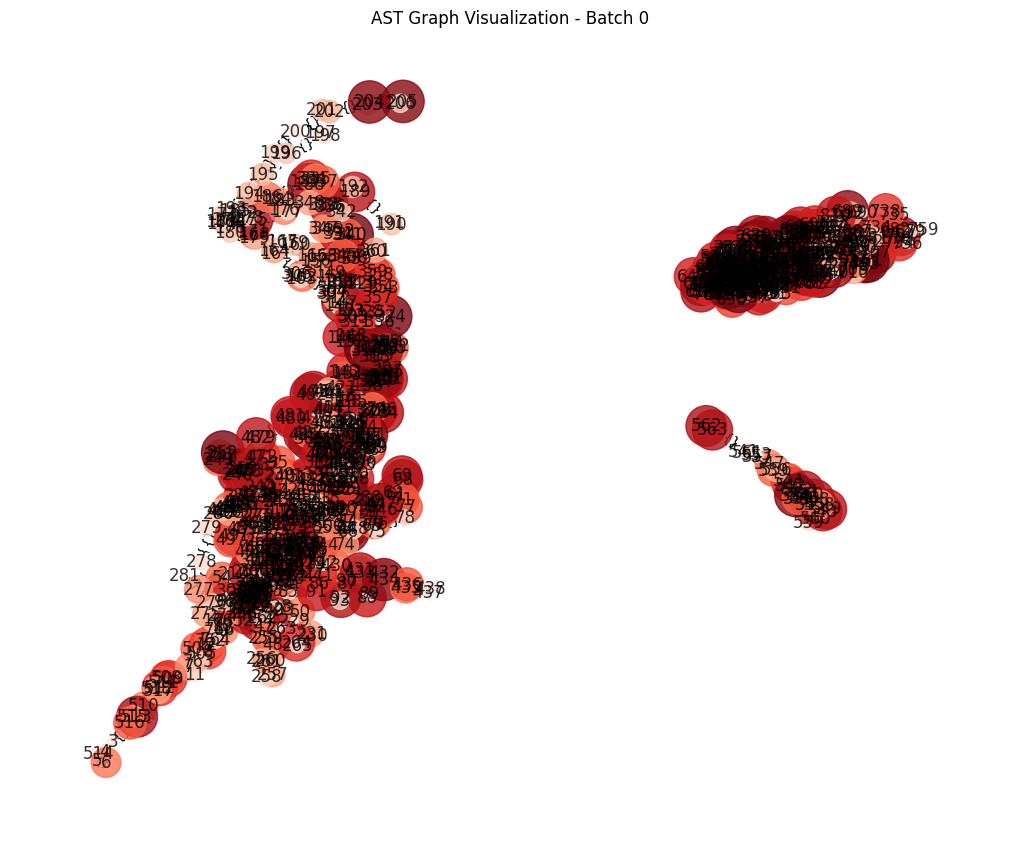

<Figure size 1000x800 with 0 Axes>

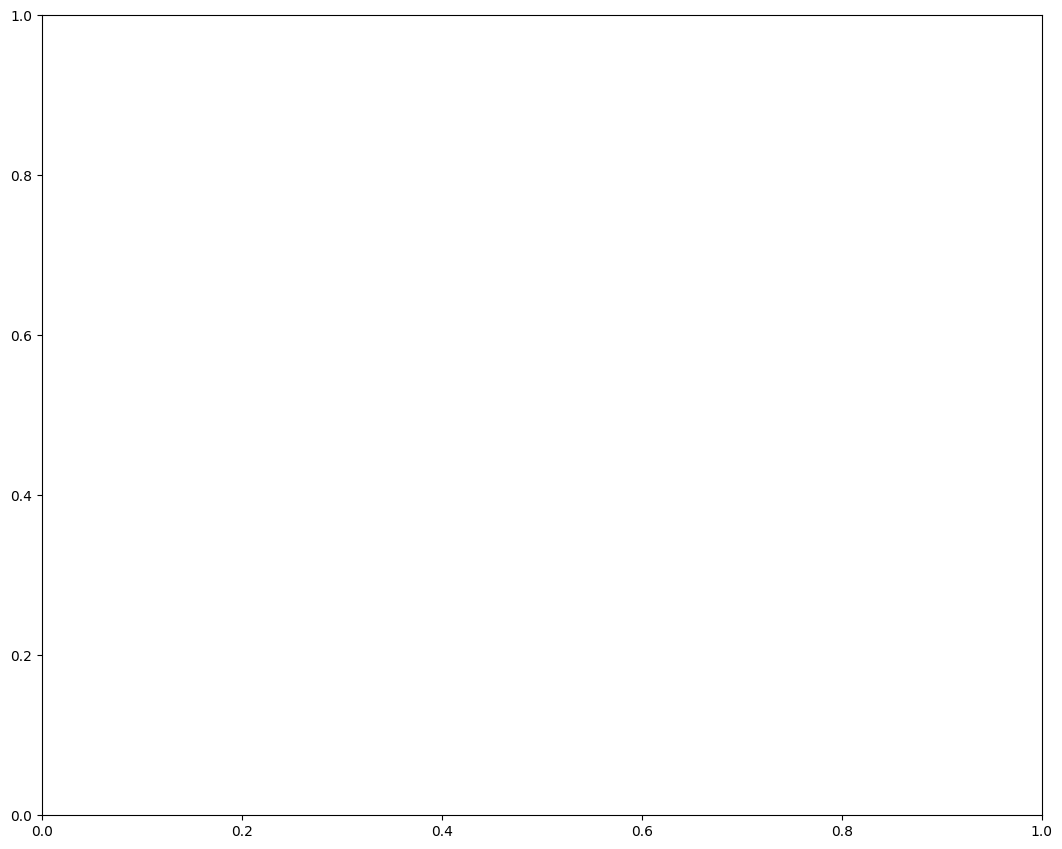

In [122]:
train(args, device, train_loader, val_loader, combined_model, optimizer, loss_function)

In [111]:
combined_model.devign_model.set_explainer_mode(False)
test_mode = False

In [39]:
graph_explanations = train(args, device, train_loader, val_loader, combined_model, optimizer, loss_function)

Epoch: 0
batch_idx: 0


/tmp/ipykernel_462097/1677906440.py:629: UserWarning: An invalid module MaxPool1d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False) is detected. Saved gradients will
                be used as the gradients of the module's input tensor.
                See MaxPool1d as an example.
  warnings.warn(
/home/ngan/.local/lib/python3.8/site-packages/torch/nn/modules/module.py:1344: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
/tmp/ipykernel_462097/1677906440.py:629: UserWarning: An invalid module MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False) is detected. Saved gradients will
                be used as the gradients of the module's input t

edge_index is a tuple
Node features shape: torch.Size([6640, 1])
Edge index shape: torch.Size([2, 50170])


In [43]:
!pip uninstall -y dive-into-graphs

Found existing installation: dive-into-graphs 1.1.0
Uninstalling dive-into-graphs-1.1.0:
  Successfully uninstalled dive-into-graphs-1.1.0


In [ ]:
# !pip install torch==2.0.0 torch_geometric

In [137]:
clr_model = CLRModel(num_labels=2)
devign_model = DevignModel()  # Adjust dimensions based on your data
new_model = CombinedModel(clr_model, devign_model).to(device)
model_path = '/home/ngan/Documents/SamVulDetection/saved_models/model_epoch_11.pth'
new_model.load_state_dict(torch.load(model_path))
new_model.eval()  # Set the model to evaluation mode
# Kiểm tra xem có sử dụng GPU không
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Đặt mô hình lên thiết bị
new_model.to(device)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


CombinedModel(
  (clr_model): CLRModel(
    (model): RobertaForSequenceClassification(
      (roberta): RobertaModel(
        (embeddings): RobertaEmbeddings(
          (word_embeddings): Embedding(50265, 768, padding_idx=1)
          (position_embeddings): Embedding(514, 768, padding_idx=1)
          (token_type_embeddings): Embedding(1, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (encoder): RobertaEncoder(
          (layer): ModuleList(
            (0-11): 12 x RobertaLayer(
              (attention): RobertaAttention(
                (self): RobertaSelfAttention(
                  (query): Linear(in_features=768, out_features=768, bias=True)
                  (key): Linear(in_features=768, out_features=768, bias=True)
                  (value): Linear(in_features=768, out_features=768, bias=True)
                  (dropout): Dropout(p=0.1, inplace=False)
                )
     

In [26]:
!pip install seaborn


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import torch

print(all_preds)

[0 0 0 ... 0 0 0]


batch_idx: 0, total_batches: 160
Sequence logits shape: torch.Size([32, 1])
Graph outputs (zeros) shape: torch.Size([32, 1])
Combined logits shape: torch.Size([32, 2])
batch_idx: 1, total_batches: 160
Sequence logits shape: torch.Size([32, 1])
Graph outputs shape before pooling: torch.Size([1])
Graph outputs shape after adjustment: torch.Size([32, 1])
Combined logits shape: torch.Size([32, 2])
batch_idx: 2, total_batches: 160


/home/ngan/.local/lib/python3.8/site-packages/dgl/backend/pytorch/tensor.py:445: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  assert input.numel() == input.storage().size(), (


Sequence logits shape: torch.Size([32, 1])
Graph outputs shape before pooling: torch.Size([3])
Graph outputs shape after adjustment: torch.Size([32, 1])
Combined logits shape: torch.Size([32, 2])
batch_idx: 3, total_batches: 160
Sequence logits shape: torch.Size([32, 1])
Graph outputs (zeros) shape: torch.Size([32, 1])
Combined logits shape: torch.Size([32, 2])
batch_idx: 4, total_batches: 160
Sequence logits shape: torch.Size([32, 1])
Graph outputs (zeros) shape: torch.Size([32, 1])
Combined logits shape: torch.Size([32, 2])
batch_idx: 5, total_batches: 160
Sequence logits shape: torch.Size([32, 1])
Graph outputs shape before pooling: torch.Size([2])
Graph outputs shape after adjustment: torch.Size([32, 1])
Combined logits shape: torch.Size([32, 2])
batch_idx: 6, total_batches: 160
Sequence logits shape: torch.Size([32, 1])
Graph outputs (zeros) shape: torch.Size([32, 1])
Combined logits shape: torch.Size([32, 2])
batch_idx: 7, total_batches: 160
Sequence logits shape: torch.Size([32,

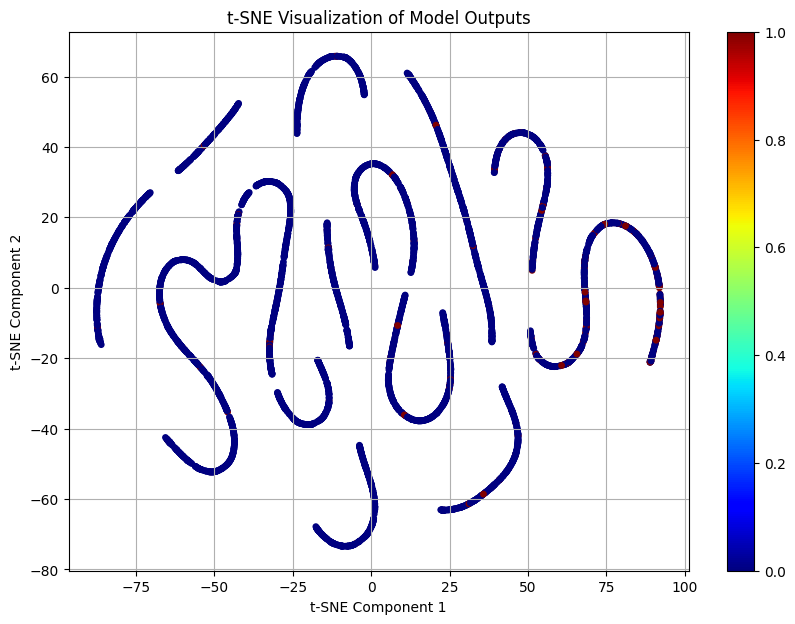

In [138]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def tsne_visualization(model, data_loader, device):
    model.eval()
    all_outputs = []
    all_labels = []

    total_batches = len(val_loader)
    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            print(f'batch_idx: {batch_idx}, total_batches: {total_batches}')
            sequence_inputs = batch['sequence_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            graph_inputs = batch['graph_features']

            if graph_inputs is not None:
                graph_inputs = graph_inputs.to(device)

            labels = batch['label'].cpu().numpy()

            # Forward pass through the model
            if graph_inputs is not None:
                outputs = model(sequence_inputs, attention_mask, graph_inputs)
            else:
                outputs = model(sequence_inputs, attention_mask)

            all_outputs.append(outputs.cpu().numpy())
            all_labels.append(labels)

    # Flatten the output and labels
    all_outputs = np.concatenate(all_outputs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # Apply t-SNE to reduce the dimensionality of the model outputs
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_results = tsne.fit_transform(all_outputs)

    # Create scatter plot of the t-SNE results
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=all_labels, cmap='jet', marker='o', s=15)
    plt.colorbar(scatter)
    plt.title('t-SNE Visualization of Model Outputs')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True)
    plt.show()

# Example usage:
# Assuming you have your validation dataloader and model
tsne_visualization(new_model, val_loader, device)


batch_idx: 0, total_batches: 160
Sequence logits shape: torch.Size([32, 1])
Graph outputs (zeros) shape: torch.Size([32, 1])
Combined logits shape: torch.Size([32, 2])
batch_idx: 1, total_batches: 160
Sequence logits shape: torch.Size([32, 1])
Graph outputs shape before pooling: torch.Size([1])
Graph outputs shape after adjustment: torch.Size([32, 1])
Combined logits shape: torch.Size([32, 2])


/home/ngan/.local/lib/python3.8/site-packages/dgl/backend/pytorch/tensor.py:445: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  assert input.numel() == input.storage().size(), (


batch_idx: 2, total_batches: 160
Sequence logits shape: torch.Size([32, 1])
Graph outputs shape before pooling: torch.Size([3])
Graph outputs shape after adjustment: torch.Size([32, 1])
Combined logits shape: torch.Size([32, 2])
batch_idx: 3, total_batches: 160
Sequence logits shape: torch.Size([32, 1])
Graph outputs (zeros) shape: torch.Size([32, 1])
Combined logits shape: torch.Size([32, 2])
batch_idx: 4, total_batches: 160
Sequence logits shape: torch.Size([32, 1])
Graph outputs (zeros) shape: torch.Size([32, 1])
Combined logits shape: torch.Size([32, 2])
batch_idx: 5, total_batches: 160
Sequence logits shape: torch.Size([32, 1])
Graph outputs shape before pooling: torch.Size([2])
Graph outputs shape after adjustment: torch.Size([32, 1])
Combined logits shape: torch.Size([32, 2])
batch_idx: 6, total_batches: 160
Sequence logits shape: torch.Size([32, 1])
Graph outputs (zeros) shape: torch.Size([32, 1])
Combined logits shape: torch.Size([32, 2])
batch_idx: 7, total_batches: 160
Seque

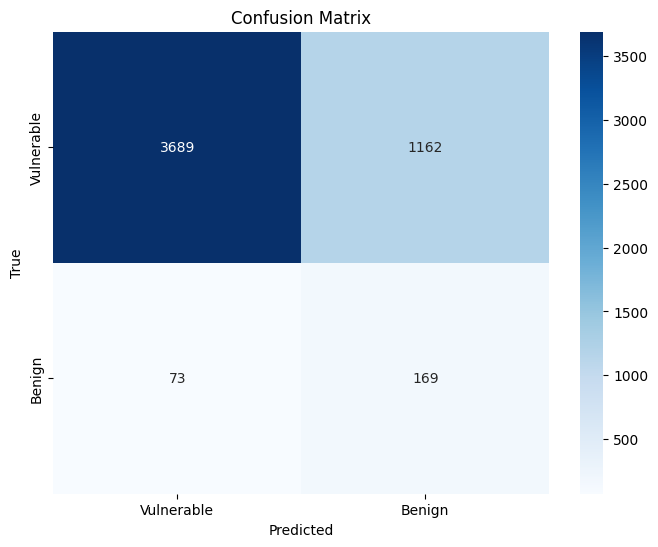

In [140]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import torch

def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Define your class labels
class_labels = ['Vulnerable', 'Benign']  # Adjust based on your labels

# Call the plotting function
new_model.eval()  # Set the model to evaluation mode
total_loss = 0
all_labels = []
all_preds = []
total_batches = len(val_loader)
with torch.no_grad():
    for batch_idx, batch in enumerate(val_loader):
        print(f'batch_idx: {batch_idx}, total_batches: {total_batches}')
        sequence_inputs = batch['sequence_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        graph_inputs = batch['graph_features']
        if graph_inputs is not None:
            graph_inputs = graph_inputs.to(device)
            # graph_inputs = [g.to(device) for g in graph_inputs]
        
        # Forward pass
        outputs = new_model(sequence_inputs, attention_mask, graph_inputs)

        # Compute the loss for this batch
        loss = loss_function(outputs, labels)
        total_loss += loss.item()  # Accumulate loss

        
        # Combined logits shape is [batch_size, 2], we need to get class predictions (0 or 1)
        preds = torch.argmax(outputs, dim=1)  # Get the predicted class for each sample
        labels_np = labels.cpu().numpy()  # Convert labels to numpy
        
        all_preds.append(preds.cpu().numpy())  # Convert predictions to numpy and append
        all_labels.append(labels_np)  # Accumulate loss.append(labels_np)
    # Flatten the accumulated predictions and labels
    all_preds = np.concatenate(all_preds).flatten()
    all_labels = np.concatenate(all_labels).flatten()
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix
    plot_confusion_matrix(cm, class_labels)
    # Calculate evaluation metrics
    # accuracy = accuracy_score(all_labels, all_preds)
    # precision = precision_score(all_labels, all_preds, average='binary')

    # recall = recall_score(all_labels, all_preds, average='binary')
    # f1 = f1_score(all_labels, all_preds, average='binary')
    # unique, counts = np.unique(all_preds, return_counts=True)
    # # print(f"Validation Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")
    # print(f"Predictions distribution: {dict(zip(unique, counts))}")
    # print(f"Validation Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")


# Train

# PHPNet

In [29]:
php_model = PhpNetGraphTokensCombine().to(device)
train_losses = train(args, device, train_loader, val_loader, php_model, optimizer, loss_function, 0)

Epoch: 0
Unfreezing Roberta parameters at epoch 0
batch_idx: 0
Pooled token shape: torch.Size([16, 12000])


/home/ngan/.local/lib/python3.8/site-packages/dgl/backend/pytorch/tensor.py:445: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  assert input.numel() == input.storage().size(), (


GGNN output shape: torch.Size([1317, 256])
x_graph.shape[-1] != 3000, got 256
Reshaped graph features: torch.Size([5, 3000])
Padded graph features: torch.Size([16, 3000])
Epoch [1/10], Step [1/1887], Loss: 1.0484
batch_idx: 1
Pooled token shape: torch.Size([16, 12000])
GGNN output shape: torch.Size([3405, 256])
x_graph.shape[-1] != 3000, got 256
Reshaped graph features: torch.Size([11, 3000])
Padded graph features: torch.Size([16, 3000])
batch_idx: 2
Pooled token shape: torch.Size([16, 12000])
GGNN output shape: torch.Size([3352, 256])
x_graph.shape[-1] != 3000, got 256
Reshaped graph features: torch.Size([5, 3000])
Padded graph features: torch.Size([16, 3000])
batch_idx: 3
Pooled token shape: torch.Size([16, 12000])
GGNN output shape: torch.Size([2136, 256])
x_graph.shape[-1] != 3000, got 256
Reshaped graph features: torch.Size([5, 3000])
Padded graph features: torch.Size([16, 3000])
batch_idx: 4
Pooled token shape: torch.Size([16, 12000])
GGNN output shape: torch.Size([3666, 256])
x_

/home/ngan/.local/lib/python3.8/site-packages/dgl/backend/pytorch/tensor.py:445: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  assert input.numel() == input.storage().size(), (


GGNN output shape: torch.Size([6150, 256])
x_graph.shape[-1] != 3000, got 256
Reshaped graph features: torch.Size([13, 3000])
Padded graph features: torch.Size([16, 3000])
Epoch [2/10], Step [1/1887], Loss: 3.8499
batch_idx: 1
Pooled token shape: torch.Size([16, 12000])
GGNN output shape: torch.Size([2662, 256])
x_graph.shape[-1] != 3000, got 256
Reshaped graph features: torch.Size([8, 3000])
Padded graph features: torch.Size([16, 3000])
batch_idx: 2
Pooled token shape: torch.Size([16, 12000])
GGNN output shape: torch.Size([4058, 256])
x_graph.shape[-1] != 3000, got 256
Reshaped graph features: torch.Size([9, 3000])
Padded graph features: torch.Size([16, 3000])
batch_idx: 3
Pooled token shape: torch.Size([16, 12000])
GGNN output shape: torch.Size([5982, 256])
x_graph.shape[-1] != 3000, got 256
Reshaped graph features: torch.Size([8, 3000])
Padded graph features: torch.Size([16, 3000])
batch_idx: 4
Pooled token shape: torch.Size([16, 12000])
GGNN output shape: torch.Size([2993, 256])
x_

KeyboardInterrupt: 

In [19]:
model = PhpNetGraphTokensCombine().to(device)
model_path = '/home/ngan/Documents/SamVulDetection/saved_models/PhpNetGraphTokensCombine_epoch_2.pth'
model.load_state_dict(torch.load(model_path))
model.eval()  # Set the model to evaluation mode
# Kiểm tra xem có sử dụng GPU không
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Đặt mô hình lên thiết bị
model.to(device)


PhpNetGraphTokensCombine(
  (embedding): Embedding(50265, 768)
  (ggnn): GatedGraphConv(
    (linears): ModuleList(
      (0-5): 6 x Linear(in_features=256, out_features=256, bias=True)
    )
    (gru): GRUCell(256, 256)
  )
  (lstm): LSTM(768, 12000, batch_first=True)
  (fc_tokens): Linear(in_features=12000, out_features=3000, bias=True)
  (fc_graph): Linear(in_features=256, out_features=3000, bias=True)
  (output_layer): Linear(in_features=6000, out_features=2, bias=True)
)

In [22]:
best_val_loss = 0.6807
save_dir = '/home/ngan/Documents/SamVulDetection/saved_models'
os.makedirs(save_dir, exist_ok=True)  # Ensure the save directory exists
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
# Freeze Roberta layers for the first `freeze_epochs` epochs
if hasattr(model, 'clr_model'):
    for param in model.clr_model.parameters():
        param.requires_grad = False
for epoch in range(args['epoch']):

    if epoch == 0:
        continue
    print(f'Epoch: {epoch}')
    
    # Save the model after each epoch
    model_name = 'PhpNetGraphTokensCombine' if isinstance(model, PhpNetGraphTokensCombine) else 'CombinedModel'
    model_path = os.path.join(save_dir, f'{model_name}_epoch_{epoch + 1}.pth')
    # torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")
    
    # Evaluate model on validation set
    val_loss = evaluate(args, device, val_loader, model, loss_function)
    print(f"Epoch {epoch + 1}/{args['epoch']}, Validation Loss: {val_loss:.4f}")

    # Optionally save the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_path = os.path.join(save_dir, 'best_model.pth')
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved to {best_model_path} with validation loss: {best_val_loss:.4f}")


Epoch: 1
Model saved to /home/ngan/Documents/SamVulDetection/saved_models/PhpNetGraphTokensCombine_epoch_2.pth
Pooled token shape: torch.Size([16, 12000])
Pooled token shape: torch.Size([16, 12000])
GGNN output shape: torch.Size([933, 256])
x_graph.shape[-1] != 3000, got 256
Reshaped graph features: torch.Size([3, 3000])
Padded graph features: torch.Size([16, 3000])
Pooled token shape: torch.Size([16, 12000])
GGNN output shape: torch.Size([637, 256])
x_graph.shape[-1] != 3000, got 256
Reshaped graph features: torch.Size([1, 3000])
Padded graph features: torch.Size([16, 3000])
Pooled token shape: torch.Size([16, 12000])
GGNN output shape: torch.Size([150, 256])
x_graph.shape[-1] != 3000, got 256
Reshaped graph features: torch.Size([1, 3000])
Padded graph features: torch.Size([16, 3000])
Pooled token shape: torch.Size([16, 12000])
Pooled token shape: torch.Size([16, 12000])
Pooled token shape: torch.Size([16, 12000])
Pooled token shape: torch.Size([16, 12000])
Pooled token shape: torch.S

KeyboardInterrupt: 